# 📡 Telco Customer Churn — Full ML Pipeline
### Unified Notebook: EDA + Preprocessing + Feature Engineering + Modelling

**Business Goal:** Identify customers at risk of churning so the retention team can act *before* they leave.  
We optimise for **Recall on churners (class 1)** — missing a churner is far more costly than a false alarm.

---
| Step | Section |
|------|---------|
| 1 | Imports & Config |
| 2 | Data Loading & First Look |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Preprocessing & Feature Engineering |
| 5 | Train/Test Split & SMOTE Balancing |
| 6 | Feature Scaling |
| 7 | Model Training & Evaluation |
| 8 | Threshold Tuning |
| 9 | Final Model Comparison & Recommendation |

## Step 1 — Imports & Configuration
> Load all libraries once up-front so every step below is self-contained.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# ── Core data manipulation ─────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Sklearn: preprocessing, modelling, evaluation ─────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing  import StandardScaler, LabelEncoder
from sklearn.metrics        import (classification_report, accuracy_score,
                                    confusion_matrix, roc_auc_score,
                                    roc_curve, f1_score, ConfusionMatrixDisplay)
from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble       import (RandomForestClassifier,
                                    GradientBoostingClassifier,
                                    VotingClassifier)
from sklearn.tree           import DecisionTreeClassifier
from sklearn.svm            import SVC
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost                import XGBClassifier
from imblearn.over_sampling import SMOTE

# ── Global config ──────────────────────────────────────────────────────────
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
PALETTE       = 'Set2'
CHURN_COLORS  = {'No': '#2196F3', 'Yes': '#F44336'}  # blue=stay, red=churn

sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
print('✅  All imports loaded.')

✅  All imports loaded.


## Step 2 — Data Loading & First Look
> Read the raw CSV, check shape, types, and missing values before touching anything.

In [ ]:
# Load the raw dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# ── Detailed info table: dtype, nulls, unique count ───────────────────────
info_df = pd.DataFrame({
    'dtype'      : df.dtypes,
    'non_null'   : df.notnull().sum(),
    'null_count' : df.isnull().sum(),
    'unique'     : df.nunique()
})
display(info_df)

# Note: TotalCharges is object (not float) — has blank strings that coerce to NaN
print('\n⚠️  TotalCharges stored as string — will fix in preprocessing.')

,dtype,non_null,null_count,unique
customerID,object,7043,0,7043
gender,object,7043,0,2
SeniorCitizen,int64,7043,0,2
Partner,object,7043,0,2
Dependents,object,7043,0,2
tenure,int64,7043,0,73
PhoneService,object,7043,0,2
MultipleLines,object,7043,0,3
InternetService,object,7043,0,3
OnlineSecurity,object,7043,0,3



⚠️  TotalCharges stored as string — will fix in preprocessing.


In [ ]:
# ── Statistical summary for numeric columns ───────────────────────────────
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Step 3 — Exploratory Data Analysis (EDA)
> Understand distributions, class imbalance, and feature–churn relationships.
> Every visualisation below comes with a comment explaining *what* it shows and *why* it matters for modelling.

### 3.1 — Target Distribution (Churn)
> **Purpose:** Quantify class imbalance — knowing the ratio of churners vs. non-churners
> guides our choice of resampling strategy and evaluation metric.

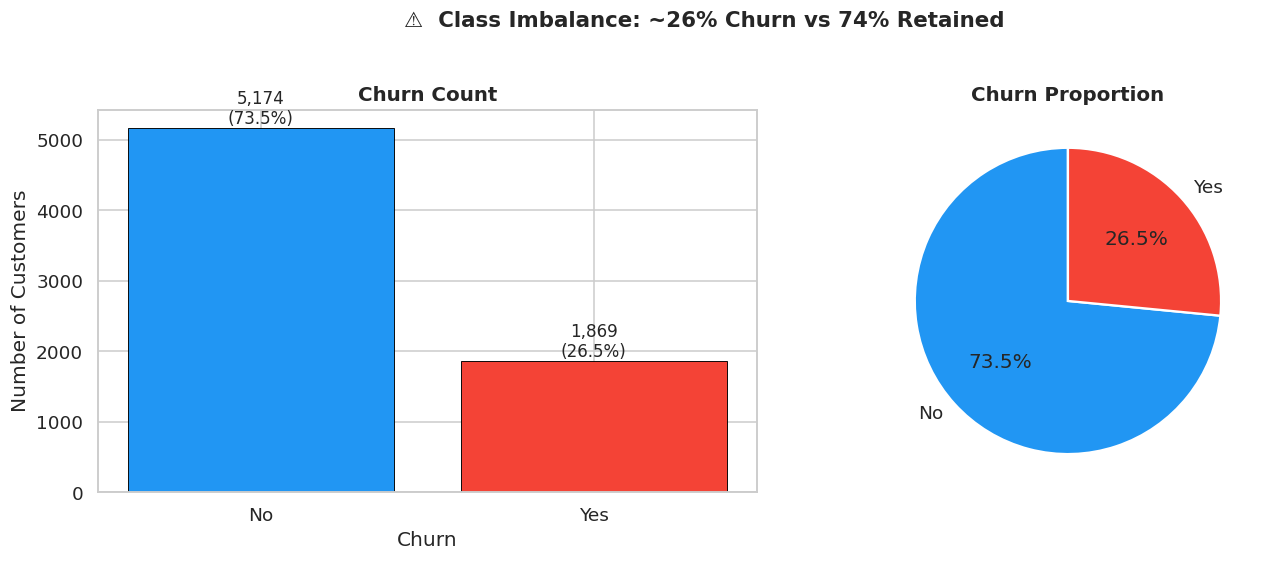

Churn rate: 26.54%  |  Dataset is imbalanced → SMOTE will be applied on training data only.


In [ ]:
# ── Target distribution: count + percentage pie ───────────────────────────
# WHY: Reveals class imbalance (~26% churn). If we ignore this, models will
#      naively predict 'No' for everyone and still get 74% accuracy — useless.
#      This motivates SMOTE in Step 5.

churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar chart
colors = [CHURN_COLORS['No'], CHURN_COLORS['Yes']]
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='black', linewidth=0.6)
for i, (label, val) in enumerate(churn_counts.items()):
    axes[0].text(i, val + 50, f'{val:,}\n({churn_pct[label]:.1f}%)', ha='center', fontsize=11)
axes[0].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn'); axes[0].set_ylabel('Number of Customers')

# Right: pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor':'white', 'linewidth':1.5})
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.suptitle('⚠️  Class Imbalance: ~26% Churn vs 74% Retained', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Churn rate: {churn_pct["Yes"]:.2f}%  |  Dataset is imbalanced → SMOTE will be applied on training data only.')

### 3.2 — Numerical Feature Distributions
> **Purpose:** Inspect the shape of each numerical feature (skew, outliers, range).
> This tells us whether scaling is needed and flags potential data-quality issues.

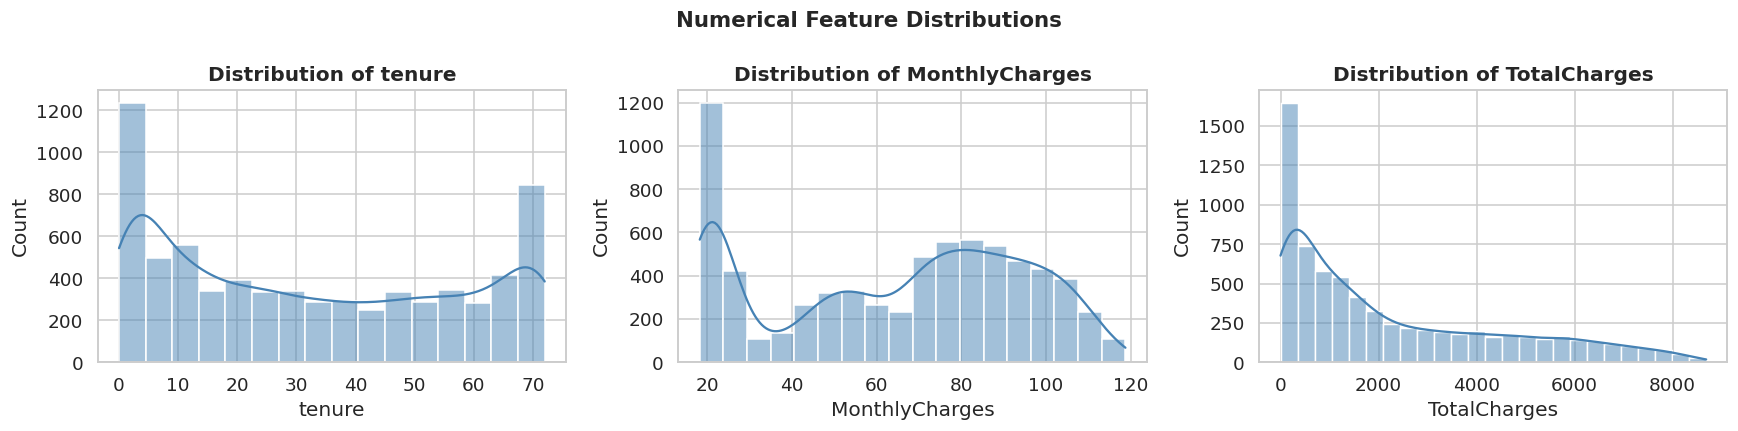

In [ ]:
# ── Fix TotalCharges type early for EDA (don't modify original df) ─────────
df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')
df_eda['TotalCharges'].fillna(df_eda['MonthlyCharges'] * df_eda['tenure'], inplace=True)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# WHY: Histograms + KDE tell us if features are normally distributed or skewed.
#      tenure is right-skewed (many new customers); TotalCharges is bimodal.
#      StandardScaler will normalise these before feeding to distance-based models.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df_eda[col], kde=True, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Count')
plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 — Numerical Features vs Churn
> **Purpose:** Compare distributions for churned vs. retained customers.
> Overlapping KDE curves + boxplots reveal which features *separate* the two classes — these will be important predictors.

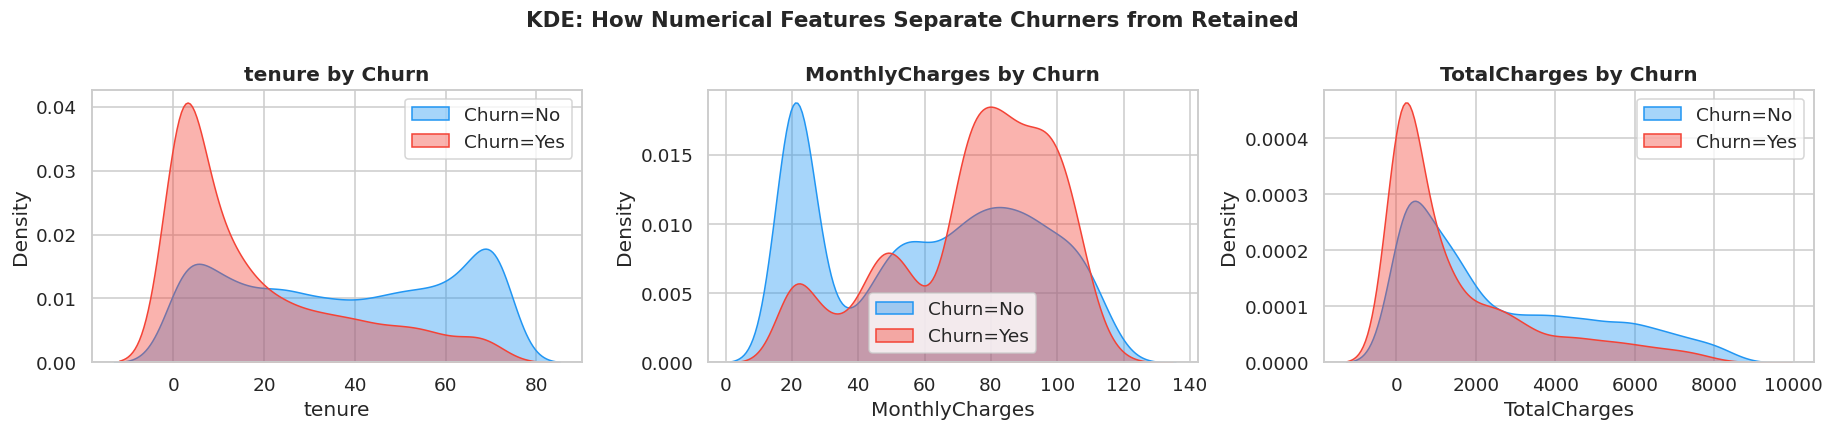

In [ ]:
# ── KDE overlay per numerical feature split by Churn ──────────────────────
# WHY: Separation between the two KDE curves = predictive power.
#      - tenure: churners cluster at low tenure → new customers leave faster.
#      - MonthlyCharges: churners pay more monthly → high bill = dissatisfaction signal.
#      - TotalCharges: partially driven by tenure (correlated), inspect carefully.

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, col in zip(axes, num_cols):
    for churn_val, color in [('No', CHURN_COLORS['No']), ('Yes', CHURN_COLORS['Yes'])]:
        subset = df_eda[df_eda['Churn'] == churn_val][col]
        sns.kdeplot(subset, ax=ax, fill=True, alpha=0.4, color=color, label=f'Churn={churn_val}')
    ax.set_title(f'{col} by Churn', fontweight='bold')
    ax.set_xlabel(col); ax.legend()
plt.suptitle('KDE: How Numerical Features Separate Churners from Retained', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

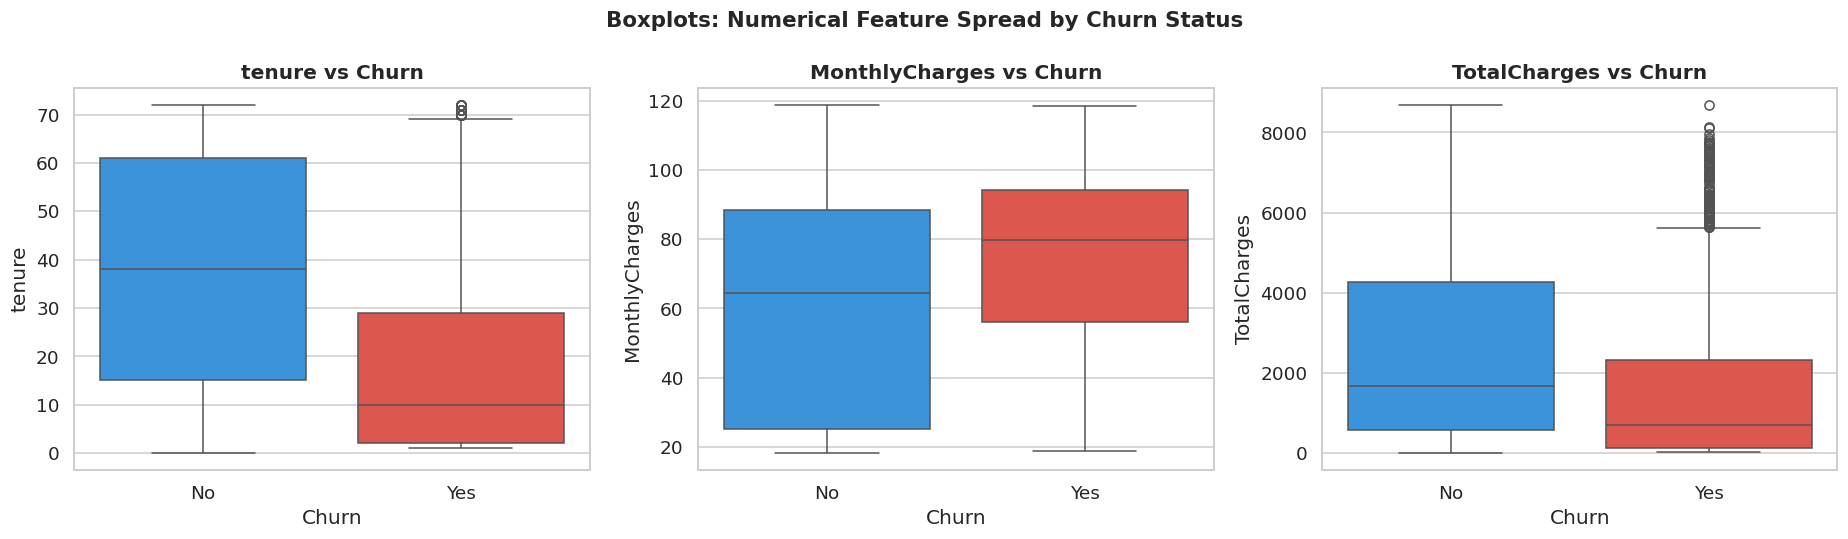

In [ ]:
# ── Boxplots: median & spread per Churn group ─────────────────────────────
# WHY: Boxplots show median, IQR, and outliers.
#      Churners have significantly lower median tenure (short stay before leaving)
#      and higher median MonthlyCharges (price sensitivity is a churn driver).

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df_eda, x='Churn', y=col, ax=ax,
                palette=CHURN_COLORS, order=['No', 'Yes'])
    ax.set_title(f'{col} vs Churn', fontweight='bold')
plt.suptitle('Boxplots: Numerical Feature Spread by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 — Pairplot of Numerical Features
> **Purpose:** View all pairwise relationships at once, coloured by churn.
> Reveals correlations between features (multicollinearity) and cluster separation.

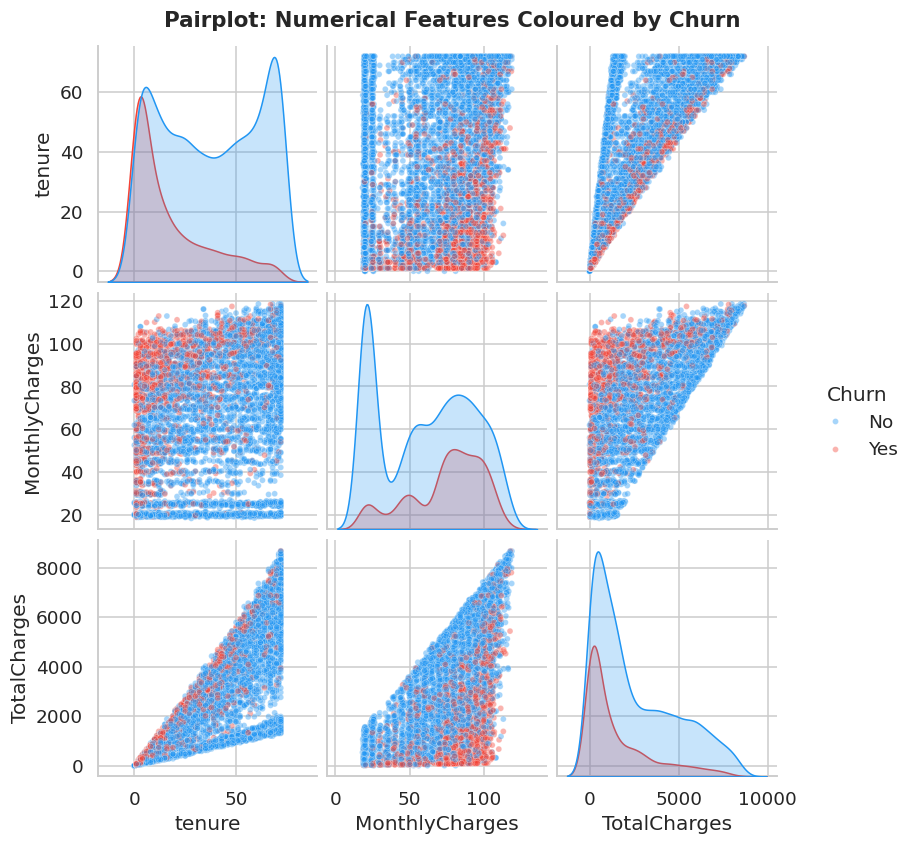

In [ ]:
# ── Pairplot: all numerical features coloured by Churn ────────────────────
# WHY: The tenure vs TotalCharges plot shows a near-linear relationship,
#      indicating strong multicollinearity. We'll engineer 'avg_monthly_spend'
#      in Step 4 to capture that signal without duplication.
#      The churn cluster (orange) sits in the low-tenure, high-charge region.

g = sns.pairplot(
    df_eda[num_cols + ['Churn']],
    hue='Churn', palette=CHURN_COLORS,
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde'
)
g.fig.suptitle('Pairplot: Numerical Features Coloured by Churn', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### 3.5 — Correlation Heatmap
> **Purpose:** Detect multicollinearity between numerical features.
> High correlation between predictors can hurt linear models and inflate feature importance.

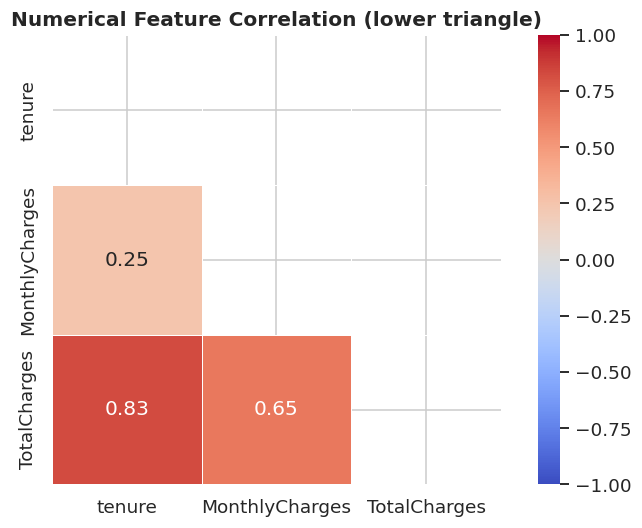

⚠️  TotalCharges–tenure correlation is very high → potential multicollinearity.


In [ ]:
# ── Correlation heatmap (numeric columns only) ────────────────────────────
# WHY: TotalCharges and tenure are highly correlated (~0.83), expected since
#      TotalCharges ≈ MonthlyCharges × tenure. Including both in a linear model
#      causes multicollinearity. Our engineered feature 'avg_monthly_spend'
#      (Step 4) summarises this relationship more cleanly.

fig, ax = plt.subplots(figsize=(7, 5))
corr = df_eda[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Numerical Feature Correlation (lower triangle)', fontweight='bold')
plt.tight_layout()
plt.show()
print('⚠️  TotalCharges–tenure correlation is very high → potential multicollinearity.')

### 3.6 — Categorical Feature Distributions & Churn Rates
> **Purpose:** For every categorical feature, show (1) its raw distribution and
> (2) the churn rate per category — this reveals which categories are *high-risk*.

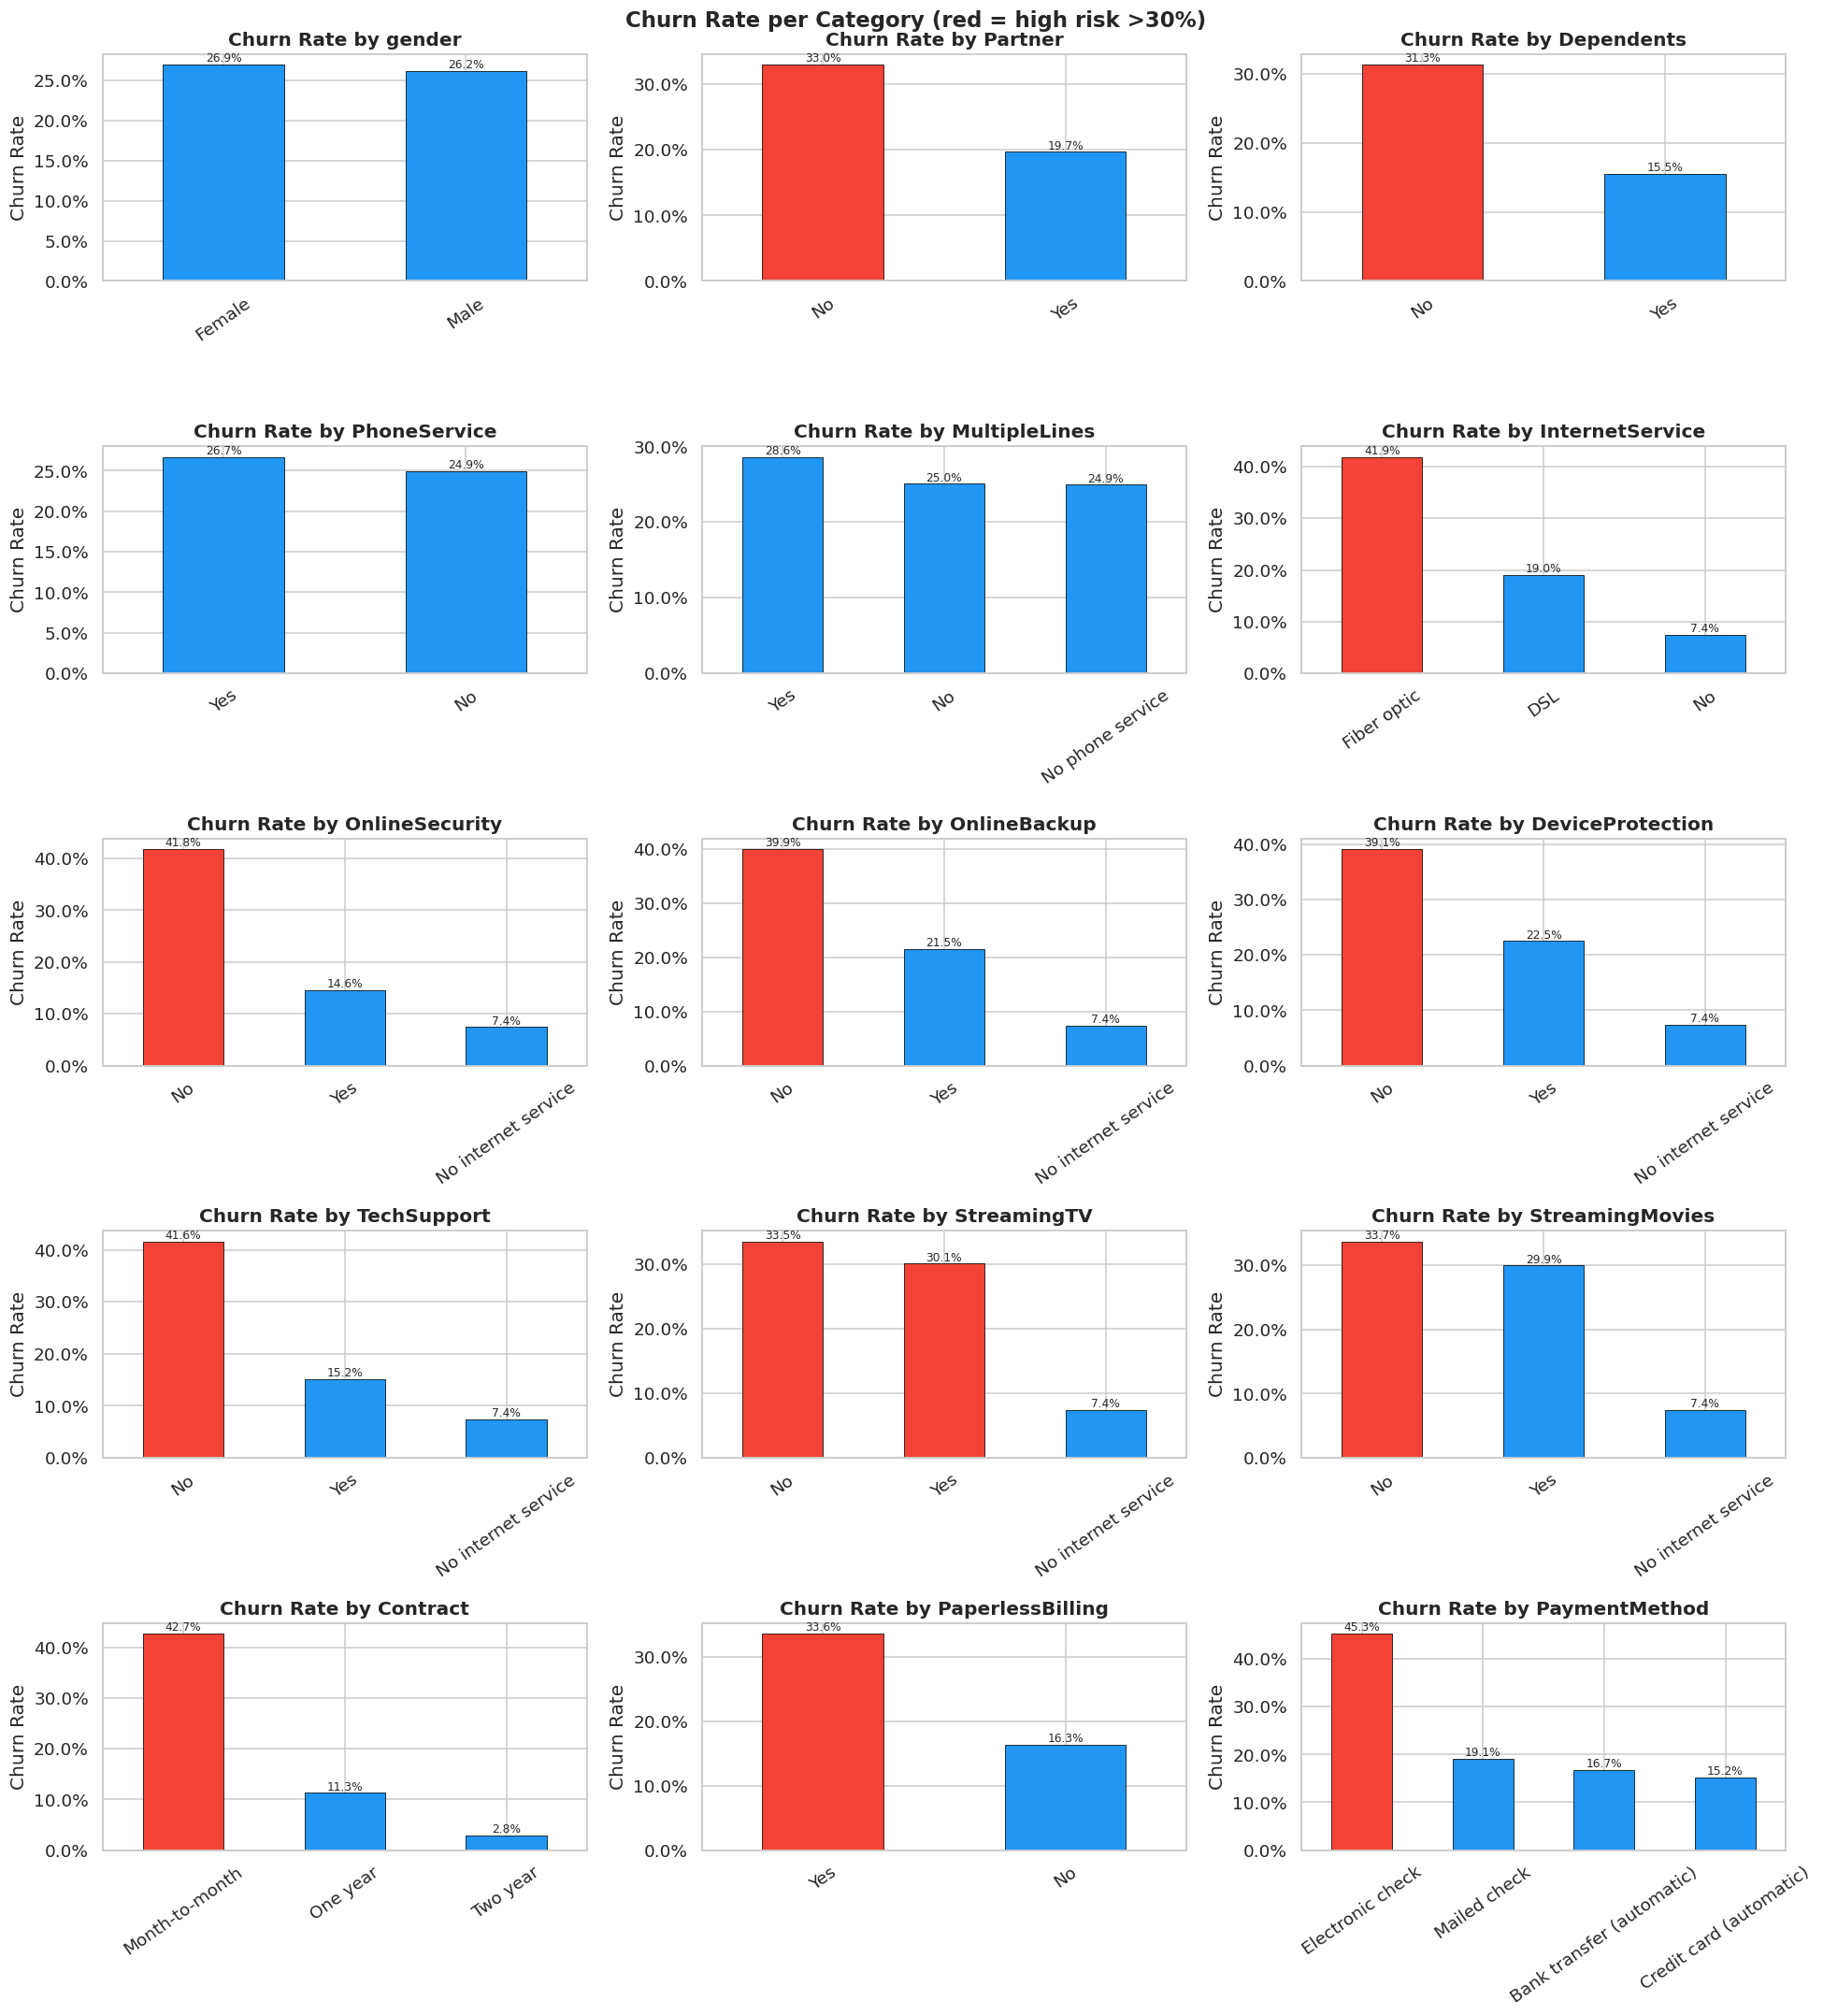

In [ ]:
# ── Churn rate per categorical feature ────────────────────────────────────
# WHY: Instead of raw counts, churn *rate* normalises for category size and
#      directly answers 'which group churns most?'. This is the business-relevant view.
#      Key findings:
#        - Contract=Month-to-month has by far the highest churn rate (~43%)
#        - No OnlineSecurity / TechSupport → higher churn
#        - Fiber optic internet users churn more (possibly price-related)

cat_cols = [c for c in df_eda.select_dtypes('object').columns
            if c not in ('customerID', 'Churn')]

# Encode churn as 0/1 for rate computation
df_eda['Churn_num'] = (df_eda['Churn'] == 'Yes').astype(int)

n = len(cat_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df_eda.groupby(col)['Churn_num'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i],
                   color=['#F44336' if v > 0.3 else '#2196F3' for v in churn_rate.values],
                   edgecolor='black', linewidth=0.5)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=35)
    # Add value labels on bars
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1%}',
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=8)

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate per Category (red = high risk >30%)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.7 — Contract Type & Tenure: Key Churn Drivers
> **Purpose:** Deep-dive into the two strongest predictors identified above.
> Stacked histograms clearly show *where* in the customer lifecycle churn is concentrated.

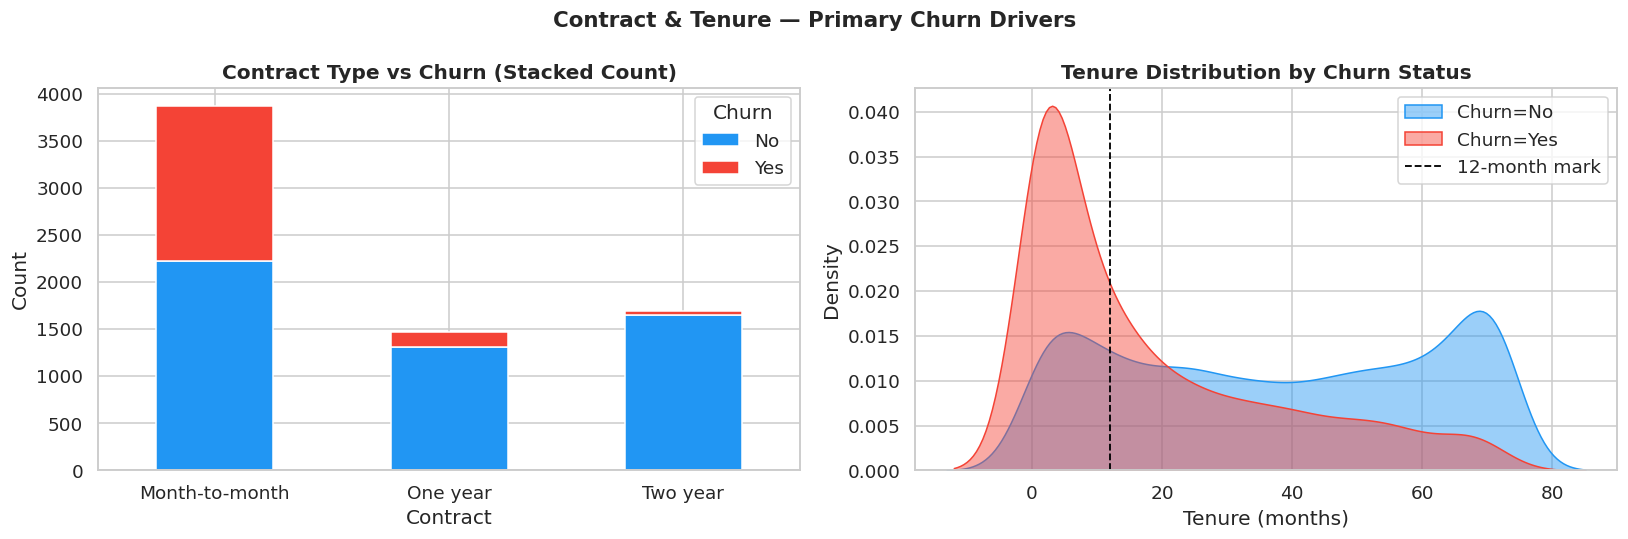

In [ ]:
# ── Contract type: stacked count + tenure KDE by Churn ────────────────────
# WHY: Month-to-month contracts have very high churn; 2-year contracts barely churn.
#      Tenure KDE shows churners cluster in the first 12 months —
#      the 'danger zone' for customer loss.
#      Business action: target customers with <12 months tenure on monthly contracts.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: stacked bars — contract type split by churn
contract_churn = df_eda.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(kind='bar', stacked=True, ax=axes[0],
                    color=[CHURN_COLORS['No'], CHURN_COLORS['Yes']],
                    edgecolor='white')
axes[0].set_title('Contract Type vs Churn (Stacked Count)', fontweight='bold')
axes[0].set_xlabel('Contract'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Churn')

# Right: tenure KDE split by Churn
for churn_val, color in [('No', CHURN_COLORS['No']), ('Yes', CHURN_COLORS['Yes'])]:
    sns.kdeplot(df_eda[df_eda['Churn']==churn_val]['tenure'],
                ax=axes[1], fill=True, alpha=0.45, color=color, label=f'Churn={churn_val}')
axes[1].axvline(12, color='black', linestyle='--', linewidth=1.2, label='12-month mark')
axes[1].set_title('Tenure Distribution by Churn Status', fontweight='bold')
axes[1].set_xlabel('Tenure (months)'); axes[1].legend()

plt.suptitle('Contract & Tenure — Primary Churn Drivers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.8 — Monthly Charges vs Total Charges (Scatter by Contract)
> **Purpose:** Visualise the interaction between spending level and contract type,
> split by churn status — a 3-way relationship in one chart.

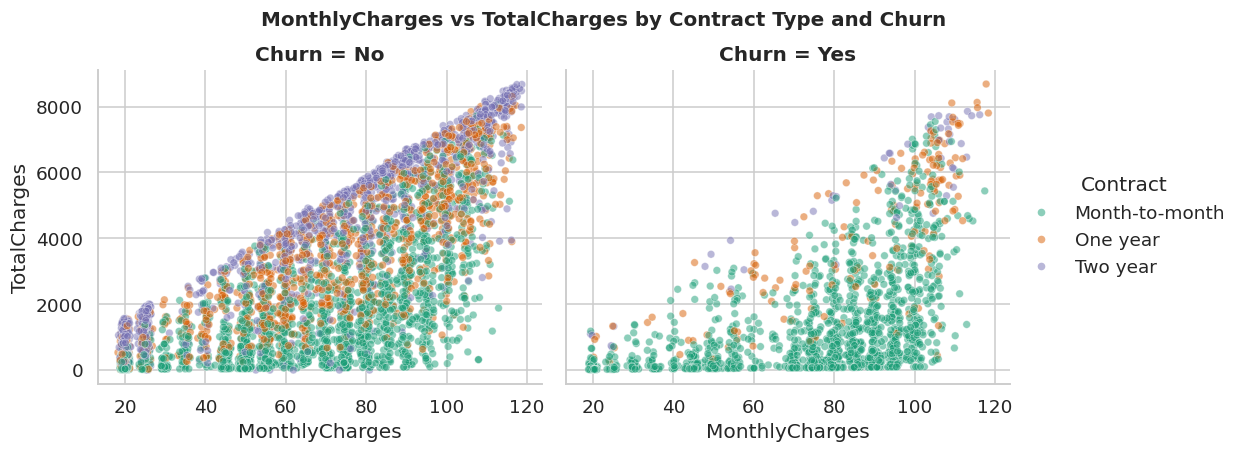

In [ ]:
# ── Scatter: MonthlyCharges vs TotalCharges, hue=Contract, col=Churn ────────
# WHY: Among churned customers (right panel), most have high MonthlyCharges
#      but low TotalCharges (new, expensive, and already leaving).
#      Among retained, high-charge customers stay long (top-right cluster).
#      This validates our 'avg_monthly_spend' engineered feature.

g = sns.relplot(
    data=df_eda, x='MonthlyCharges', y='TotalCharges',
    hue='Contract', col='Churn',
    alpha=0.5, s=25,
    palette='Dark2',
    height=4, aspect=1.2
)
g.set_titles('Churn = {col_name}', fontweight='bold')
g.fig.suptitle('MonthlyCharges vs TotalCharges by Contract Type and Churn',
               fontsize=13, fontweight='bold', y=1.03)
plt.show()

## Step 4 — Preprocessing & Feature Engineering
> Transform raw data into model-ready features:
> fix types, encode categories, clean inconsistencies, engineer new signals.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Step 4.1 — Work on a clean copy
# Always keep the raw df intact so we can re-run EDA without re-loading.
# ════════════════════════════════════════════════════════════════════════════
data = df.copy()

# ── Drop customerID — no predictive value, just a row identifier ─────────
data.drop('customerID', axis=1, inplace=True)

# ── Fix TotalCharges: stored as string with blank strings for new customers ─
# TotalCharges ≈ MonthlyCharges × tenure, so we fill NaN with that product.
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(data['MonthlyCharges'] * data['tenure'], inplace=True)

# ── Remove duplicates ─────────────────────────────────────────────────────
before = len(data)
data.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(data)}')

# ── Encode target: Yes→1, No→0 ───────────────────────────────────────────
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})
print(f'Data shape after cleaning: {data.shape}')

Duplicates removed: 22
Data shape after cleaning: (7021, 20)


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Step 4.2 — Fix logical inconsistencies in service columns
#
# Problem: when InternetService=='No', dependent service columns show
#          'No internet service' instead of 'No' → artificial extra category.
# Fix:     overwrite those cells with plain 'No'.
# Same logic for PhoneService → MultipleLines.
# ════════════════════════════════════════════════════════════════════════════
internet_deps = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in internet_deps:
    data.loc[data['InternetService'] == 'No', col] = 'No'

data.loc[data['PhoneService'] == 'No', 'MultipleLines'] = 'No'

print('Service column categories after fix:')
for col in internet_deps + ['MultipleLines']:
    print(f'  {col}: {data[col].unique()}')

Service column categories after fix:
  OnlineSecurity: ['No' 'Yes']
  OnlineBackup: ['Yes' 'No']
  DeviceProtection: ['No' 'Yes']
  TechSupport: ['No' 'Yes']
  StreamingTV: ['No' 'Yes']
  StreamingMovies: ['No' 'Yes']
  MultipleLines: ['No' 'Yes']


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Step 4.3 — Encode binary Yes/No columns and gender
# Using manual mapping (not get_dummies) keeps column names clean and explicit.
# ════════════════════════════════════════════════════════════════════════════
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
data[binary_cols] = data[binary_cols].replace({'Yes': 1, 'No': 0})
data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})

# ── One-hot encode remaining object columns (Contract, InternetService, PaymentMethod)
remaining_cat = [c for c in data.columns if data[c].dtype == 'object']
print(f'Columns needing OHE: {remaining_cat}')
data = pd.get_dummies(data, columns=remaining_cat, drop_first=True)

# ── Convert any bool columns to int (get_dummies outputs bool in pandas ≥1.5)
bool_cols = data.select_dtypes('bool').columns
data[bool_cols] = data[bool_cols].astype(int)

print(f'Shape after encoding: {data.shape}')
print(f'Remaining nulls: {data.isnull().sum().sum()}')

Columns needing OHE: ['InternetService', 'Contract', 'PaymentMethod']
Shape after encoding: (7021, 24)
Remaining nulls: 0


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Step 4.4 — Feature Engineering
#
# avg_monthly_spend : TotalCharges / (tenure+1)
#   Captures how much a customer pays on average per month across their history.
#   Smoothed with +1 to avoid divide-by-zero for new customers (tenure=0).
#
# is_high_value     : 1 if MonthlyCharges > 75th percentile
#   Flags customers the company most wants to retain (revenue impact).
#
# addon_count       : total number of add-on services subscribed
#   Proxy for engagement/stickiness. More services → harder to leave.
# ════════════════════════════════════════════════════════════════════════════
data['avg_monthly_spend'] = data['TotalCharges'] / (data['tenure'] + 1)

high_val_threshold = data['MonthlyCharges'].quantile(0.75)
data['is_high_value'] = (data['MonthlyCharges'] > high_val_threshold).astype(int)

addon_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']
data['addon_count'] = data[addon_services].sum(axis=1)

print('✅  Engineered features added: avg_monthly_spend, is_high_value, addon_count')
print(f'Final feature set: {data.shape[1] - 1} features + 1 target')
data.head(3)

✅  Engineered features added: avg_monthly_spend, is_high_value, addon_count
Final feature set: 26 features + 1 target


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,avg_monthly_spend,is_high_value,addon_count
0,0,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,1,0,14.925000,0,1
1,1,0,0,0,34,1,0,1,0,1,...,0,0,1,0,0,0,1,53.985714,0,2
2,1,0,0,0,2,1,0,1,1,0,...,0,0,0,0,0,0,1,36.050000,0,2


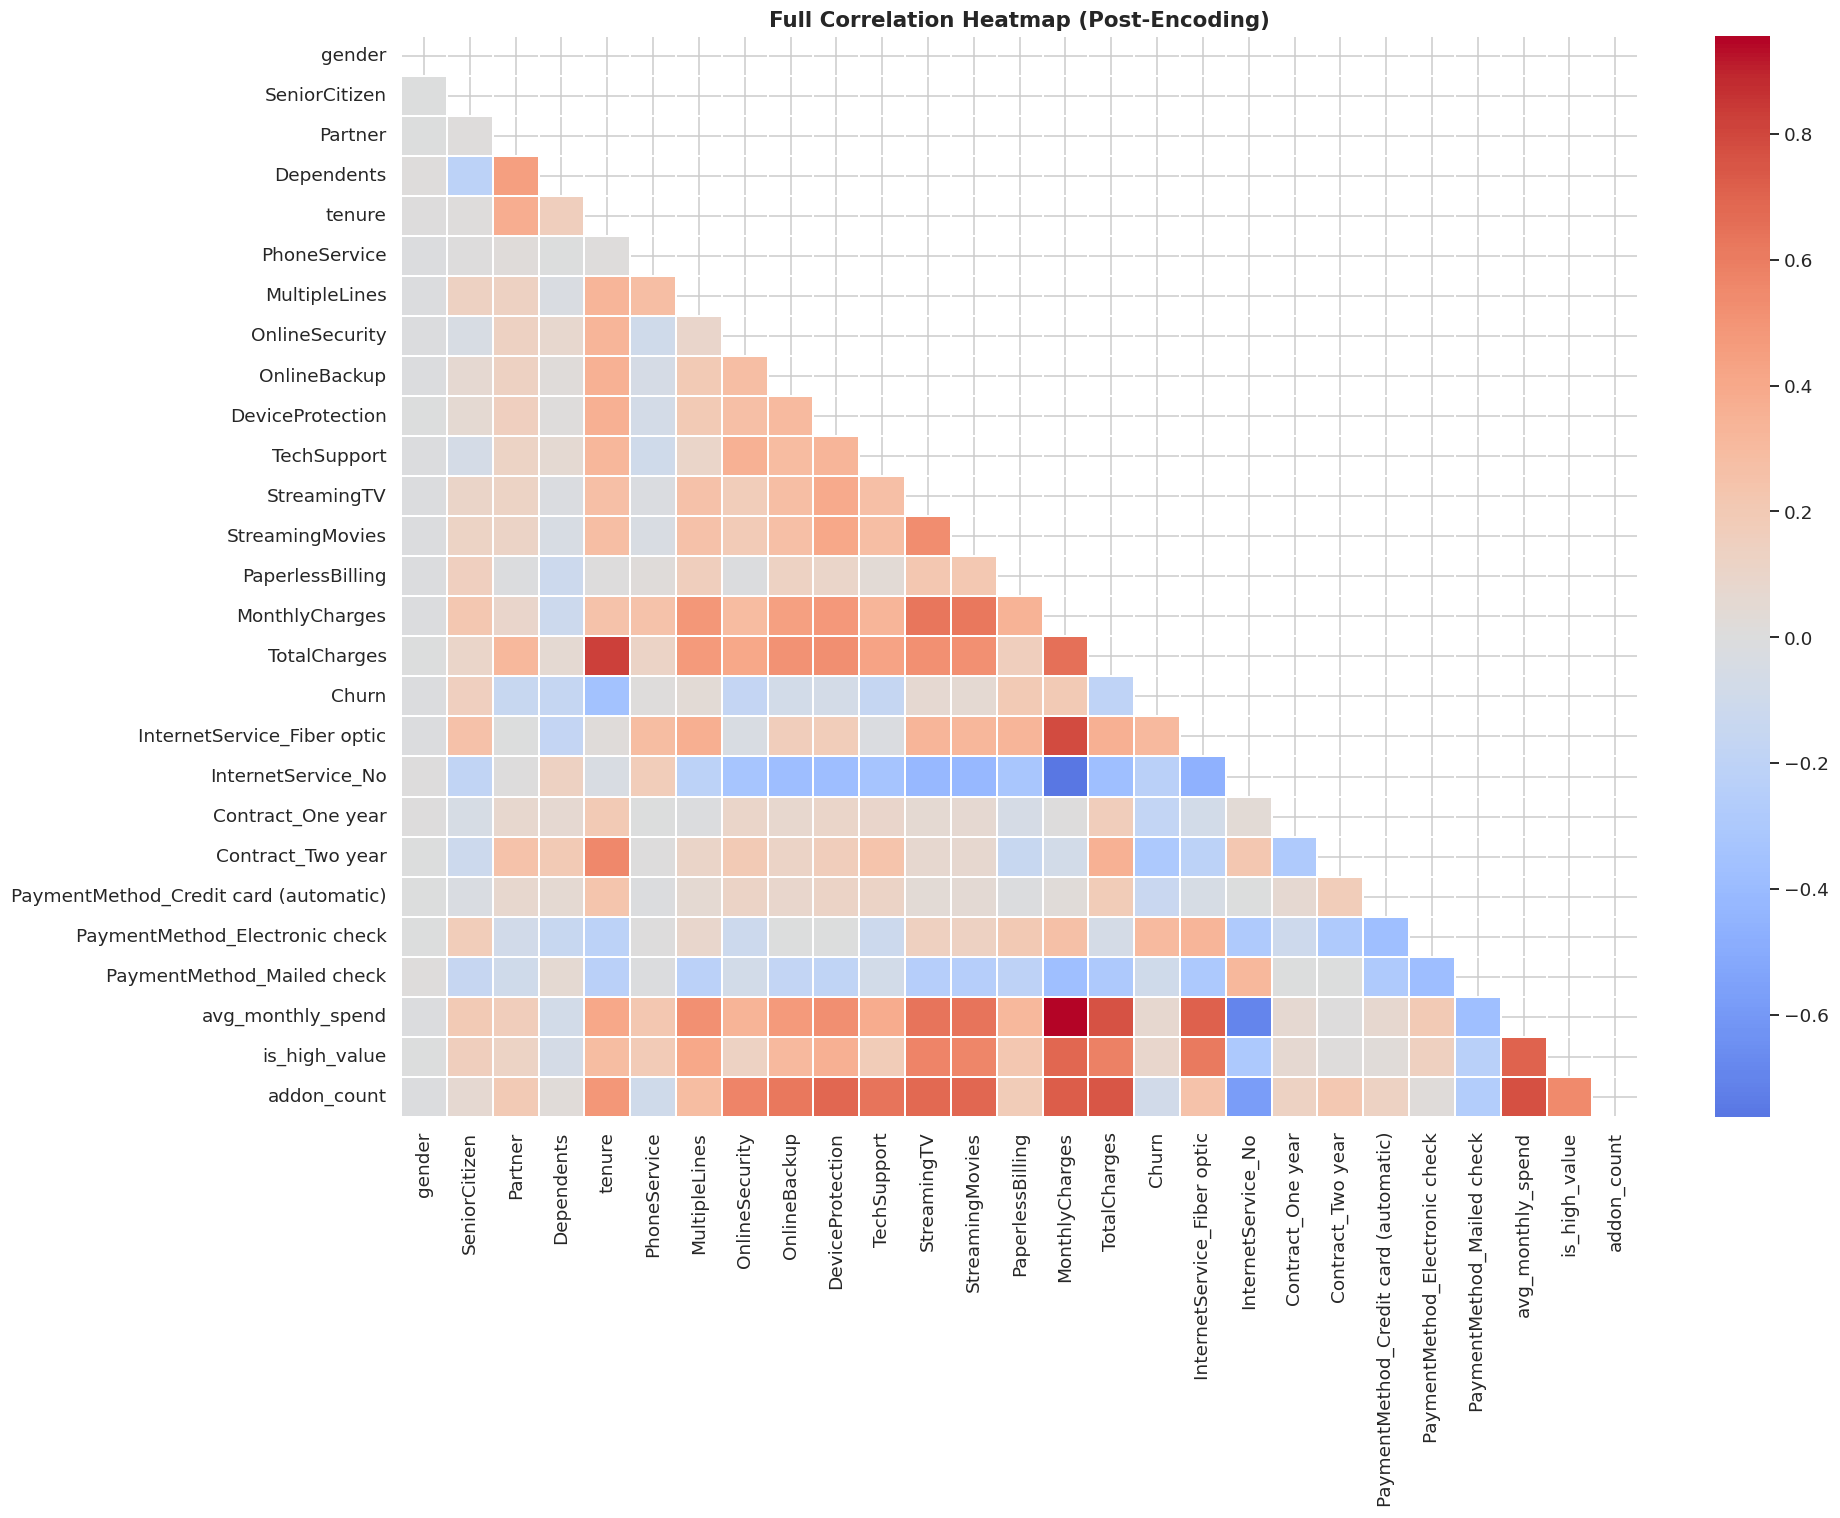

In [ ]:
# ── Full correlation heatmap after encoding ────────────────────────────────
# WHY: After one-hot encoding, this reveals if any OHE-derived columns are
#      highly correlated with each other or with the target (Churn).
#      A 'coolwarm' diverging palette makes +/- correlation easy to read.

fig, ax = plt.subplots(figsize=(18, 14))
corr_full = data.corr()
mask = np.triu(np.ones_like(corr_full, dtype=bool))
sns.heatmap(corr_full, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title('Full Correlation Heatmap (Post-Encoding)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5 — Train/Test Split & SMOTE Balancing
> **Why SMOTE on train only?** Oversampling the test set would give artificially
> optimistic metrics. We only balance training data so the model learns from equal classes,
> but we evaluate on the real-world distribution.

Train: 5,616 rows | Test: 1,405 rows
Train churn rate: 26.44% | Test churn rate: 26.48%

After SMOTE — Train size: 8,262
Churn
1    4131
0    4131
Name: count, dtype: int64


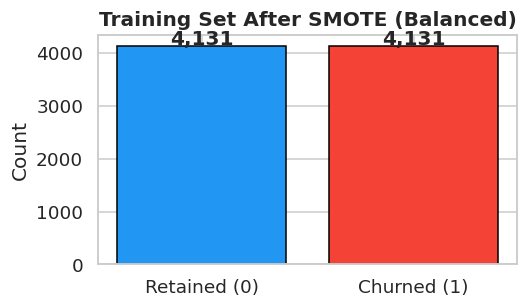

In [ ]:
X = data.drop('Churn', axis=1)
y = data['Churn']

# Stratified split: preserves 26/74 ratio in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {len(X_train):,} rows | Test: {len(X_test):,} rows')
print(f'Train churn rate: {y_train.mean():.2%} | Test churn rate: {y_test.mean():.2%}')

# SMOTE: synthesise minority (churn) samples in training set ONLY
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'\nAfter SMOTE — Train size: {len(X_train_res):,}')
print(pd.Series(y_train_res).value_counts())

# Visualise post-SMOTE balance
fig, ax = plt.subplots(figsize=(5, 3))
vc = pd.Series(y_train_res).value_counts()
ax.bar(['Retained (0)', 'Churned (1)'], vc.values,
       color=[CHURN_COLORS['No'], CHURN_COLORS['Yes']], edgecolor='black')
for i, v in enumerate(vc.values):
    ax.text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')
ax.set_title('Training Set After SMOTE (Balanced)', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## Step 6 — Feature Scaling
> Fit StandardScaler **only on training data** then apply to test.
> Fitting on test data would cause data leakage.

In [ ]:
# Columns to scale: continuous numerical features + engineered ones
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
              'avg_monthly_spend', 'addon_count']

scaler = StandardScaler()

X_train_res = X_train_res.copy()
X_test_sc   = X_test.copy()

X_train_res[scale_cols] = scaler.fit_transform(X_train_res[scale_cols])
X_test_sc[scale_cols]   = scaler.transform(X_test_sc[scale_cols])

print('✅  Scaling applied. Train/test shapes:')
print(f'   X_train_res: {X_train_res.shape} | X_test_sc: {X_test_sc.shape}')

✅  Scaling applied. Train/test shapes:
   X_train_res: (8262, 26) | X_test_sc: (1405, 26)


## Step 7 — Model Training & Evaluation
> A shared `evaluate_model()` function ensures every model is evaluated consistently.
> **Primary metric: Recall (class 1)** — catching churners is the priority.
> Secondary metrics: F1, ROC-AUC, Accuracy.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Reusable evaluation helper
# ════════════════════════════════════════════════════════════════════════════
results = []  # will collect metrics from every model

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, threshold=0.5):
    """
    Fit a model, evaluate on test set, print full report, return metrics dict.
    Supports custom probability threshold for recall optimisation.
    """
    model.fit(X_tr, y_tr)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
    else:
        y_pred = model.predict(X_te)
        y_prob = None

    acc    = accuracy_score(y_te, y_pred)
    f1     = f1_score(y_te, y_pred, average='macro')
    recall = classification_report(y_te, y_pred, output_dict=True)['1']['recall']
    roc    = roc_auc_score(y_te, y_prob) if y_prob is not None else None

    print(f'\n{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(classification_report(y_te, y_pred, target_names=['Retained','Churned']))
    print(f"  Accuracy: {acc:.4f}  |  Recall(churn): {recall:.4f}  |  F1-macro: {f1:.4f}")

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=['Retained', 'Churned'],
        colorbar=False, ax=ax, cmap='Blues'
    )
    ax.set_title(f'Confusion Matrix — {name}', fontsize=11)
    plt.tight_layout(); plt.show()

    metrics = {'model': name, 'accuracy': acc, 'f1_macro': f1,
               'recall_churn': recall, 'roc_auc': roc,
               'fitted_model': model, 'y_prob': y_prob}
    results.append(metrics)
    return metrics

### 7.1 — Logistic Regression (L2, class_weight='balanced')


  Logistic Regression
              precision    recall  f1-score   support

    Retained       0.87      0.83      0.85      1033
     Churned       0.58      0.65      0.61       372

    accuracy                           0.78      1405
   macro avg       0.72      0.74      0.73      1405
weighted avg       0.79      0.78      0.78      1405

  Accuracy: 0.7808  |  Recall(churn): 0.6452  |  F1-macro: 0.7284


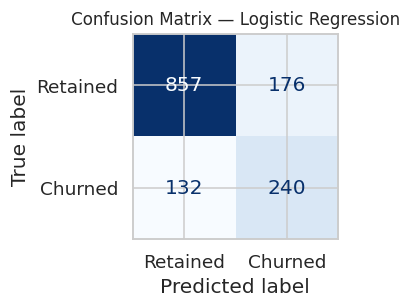

In [ ]:
# Logistic Regression: fast, interpretable baseline.
# class_weight='balanced' internally adjusts sample weights — an alternative
# to SMOTE that sometimes generalises better on linear boundaries.
lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                         C=1.0, solver='liblinear', random_state=RANDOM_STATE)
res_lr = evaluate_model('Logistic Regression', lr,
                         X_train_res, y_train_res, X_test_sc, y_test)

### 7.2 — Random Forest (Tuned via GridSearchCV)

Best RF params: {'max_depth': 7, 'min_samples_leaf': 3, 'n_estimators': 100}

  Random Forest (tuned)
              precision    recall  f1-score   support

    Retained       0.89      0.78      0.83      1033
     Churned       0.54      0.73      0.63       372

    accuracy                           0.77      1405
   macro avg       0.72      0.76      0.73      1405
weighted avg       0.80      0.77      0.78      1405

  Accuracy: 0.7673  |  Recall(churn): 0.7339  |  F1-macro: 0.7283


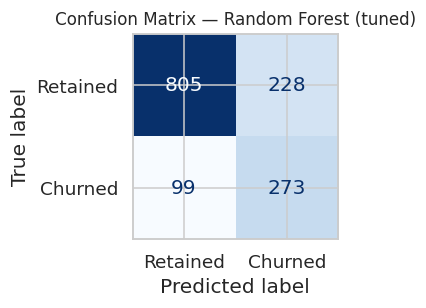

In [ ]:
# Random Forest: non-linear ensemble, robust to outliers, handles mixed features.
# Grid-searching max_depth and min_samples_leaf controls overfitting.
# Scoring on 'recall' because that is our business objective.
rf_params = {'n_estimators': [100, 200], 'max_depth': [7, 10], 'min_samples_leaf': [3, 5]}
rf_cv = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    rf_params, cv=5, scoring='recall', n_jobs=-1, verbose=0
)
rf_cv.fit(X_train_res, y_train_res)
print('Best RF params:', rf_cv.best_params_)
best_rf = rf_cv.best_estimator_
res_rf  = evaluate_model('Random Forest (tuned)', best_rf,
                          X_train_res, y_train_res, X_test_sc, y_test)

### 7.3 — Gradient Boosting (Tuned)

Best GB params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

  Gradient Boosting (tuned)
              precision    recall  f1-score   support

    Retained       0.88      0.79      0.84      1033
     Churned       0.55      0.71      0.62       372

    accuracy                           0.77      1405
   macro avg       0.72      0.75      0.73      1405
weighted avg       0.80      0.77      0.78      1405

  Accuracy: 0.7708  |  Recall(churn): 0.7070  |  F1-macro: 0.7281


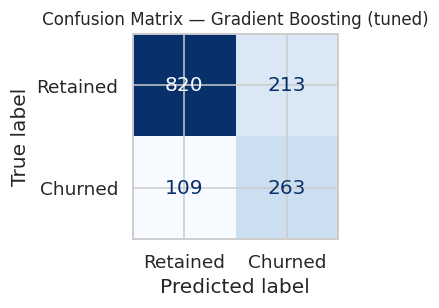

In [ ]:
# Gradient Boosting: builds trees sequentially to correct errors.
# Generally strong on tabular data. learning_rate * n_estimators controls capacity.
gb_params = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
gb_cv = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_params, cv=5, scoring='recall', n_jobs=-1, verbose=0
)
gb_cv.fit(X_train_res, y_train_res)
print('Best GB params:', gb_cv.best_params_)
best_gb = gb_cv.best_estimator_
res_gb  = evaluate_model('Gradient Boosting (tuned)', best_gb,
                          X_train_res, y_train_res, X_test_sc, y_test)

### 7.4 — XGBoost (scale_pos_weight for imbalance)

scale_pos_weight = 2.78
Best XGB params: {'colsample_bytree': 0.5, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.9}

  XGBoost (tuned)
              precision    recall  f1-score   support

    Retained       0.91      0.69      0.78      1033
     Churned       0.48      0.81      0.61       372

    accuracy                           0.72      1405
   macro avg       0.70      0.75      0.69      1405
weighted avg       0.80      0.72      0.74      1405

  Accuracy: 0.7203  |  Recall(churn): 0.8118  |  F1-macro: 0.6945


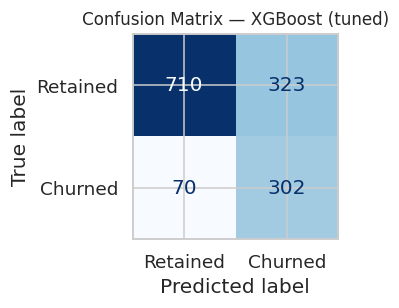

In [ ]:
# XGBoost: highly efficient gradient boosting with regularisation.
# scale_pos_weight = majority/minority ratio tells XGBoost to up-weight the
# minority class — a built-in alternative to SMOTE for tree ensembles.
neg, pos  = np.bincount(y_train)
spw       = neg / pos  # approx 2.7
print(f'scale_pos_weight = {spw:.2f}')

xgb_params = {
    'n_estimators'   : [200, 500],
    'max_depth'      : [5, 7],
    'learning_rate'  : [0.05, 0.1],
    'subsample'      : [0.7, 0.9],
    'colsample_bytree': [0.5, 0.7]
}
xgb_cv = GridSearchCV(
    XGBClassifier(scale_pos_weight=spw, use_label_encoder=False,
                  eval_metric='logloss', random_state=RANDOM_STATE),
    xgb_params, cv=5, scoring='recall', n_jobs=-1, verbose=0
)
xgb_cv.fit(X_train_res, y_train_res)
print('Best XGB params:', xgb_cv.best_params_)
best_xgb = xgb_cv.best_estimator_
res_xgb  = evaluate_model('XGBoost (tuned)', best_xgb,
                           X_train_res, y_train_res, X_test_sc, y_test)

### 7.5 — Decision Tree (Tuned)

Best DT params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}

  Decision Tree (tuned)
              precision    recall  f1-score   support

    Retained       0.87      0.76      0.81      1033
     Churned       0.51      0.69      0.58       372

    accuracy                           0.74      1405
   macro avg       0.69      0.72      0.70      1405
weighted avg       0.77      0.74      0.75      1405

  Accuracy: 0.7416  |  Recall(churn): 0.6855  |  F1-macro: 0.6984


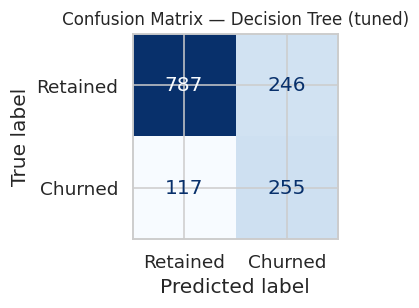

In [ ]:
# Decision Tree: interpretable, easy to explain to stakeholders.
# Highly prone to overfitting — pruning via max_depth and min_samples_leaf is critical.
dt_params = {'max_depth': [5, 10, 15], 'min_samples_split': [2, 5],
             'min_samples_leaf': [3, 5], 'criterion': ['gini', 'entropy']}
dt_cv = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    dt_params, cv=5, scoring='recall', n_jobs=-1
)
dt_cv.fit(X_train_res, y_train_res)
print('Best DT params:', dt_cv.best_params_)
best_dt = dt_cv.best_estimator_
res_dt  = evaluate_model('Decision Tree (tuned)', best_dt,
                          X_train_res, y_train_res, X_test_sc, y_test)

### 7.6 — SVM (RBF Kernel)


  SVM (RBF)
              precision    recall  f1-score   support

    Retained       0.85      0.85      0.85      1033
     Churned       0.59      0.59      0.59       372

    accuracy                           0.78      1405
   macro avg       0.72      0.72      0.72      1405
weighted avg       0.78      0.78      0.78      1405

  Accuracy: 0.7829  |  Recall(churn): 0.5914  |  F1-macro: 0.7215


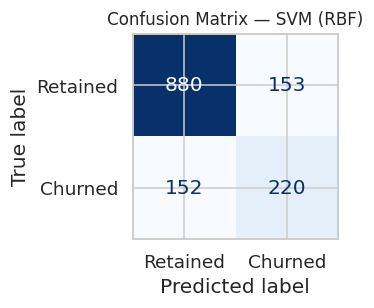

In [ ]:
# SVM: finds the maximum-margin hyperplane between classes.
# RBF kernel handles non-linear boundaries. C=10 allows some misclassifications.
# probability=True enables predict_proba needed for ROC-AUC and threshold tuning.
svm = SVC(C=10, kernel='rbf', class_weight='balanced',
           probability=True, random_state=RANDOM_STATE)
res_svm = evaluate_model('SVM (RBF)', svm,
                          X_train_res, y_train_res, X_test_sc, y_test)

### 7.7 — K-Nearest Neighbors (Tuned)

Best KNN params: {'n_neighbors': 100}

  KNN (tuned)
              precision    recall  f1-score   support

    Retained       0.92      0.67      0.77      1033
     Churned       0.48      0.84      0.61       372

    accuracy                           0.71      1405
   macro avg       0.70      0.75      0.69      1405
weighted avg       0.80      0.71      0.73      1405

  Accuracy: 0.7139  |  Recall(churn): 0.8387  |  F1-macro: 0.6914


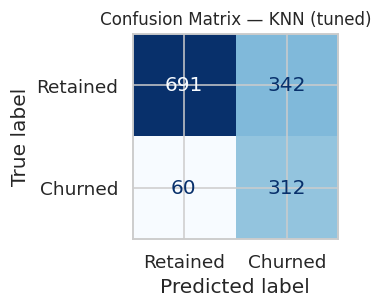

In [ ]:
# KNN: classifies based on the k most similar training points.
# Sensitive to scale (hence scaling in Step 6) and slow at inference on large data.
# We grid-search k over large values because SMOTE increased training set size.
knn_params = {'n_neighbors': [50, 100, 150, 200]}
knn_cv = GridSearchCV(
    KNeighborsClassifier(), knn_params, cv=5, scoring='recall', n_jobs=-1
)
knn_cv.fit(X_train_res, y_train_res)
print('Best KNN params:', knn_cv.best_params_)
best_knn = knn_cv.best_estimator_
res_knn  = evaluate_model('KNN (tuned)', best_knn,
                           X_train_res, y_train_res, X_test_sc, y_test)

### 7.8 — MLP Neural Network (Tuned)

Best MLP params: {'alpha': 0.0001, 'batch_size': 64, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.0005}

  MLP Neural Net (tuned)
              precision    recall  f1-score   support

    Retained       0.83      0.86      0.85      1033
     Churned       0.57      0.51      0.54       372

    accuracy                           0.77      1405
   macro avg       0.70      0.69      0.69      1405
weighted avg       0.76      0.77      0.76      1405

  Accuracy: 0.7680  |  Recall(churn): 0.5108  |  F1-macro: 0.6917


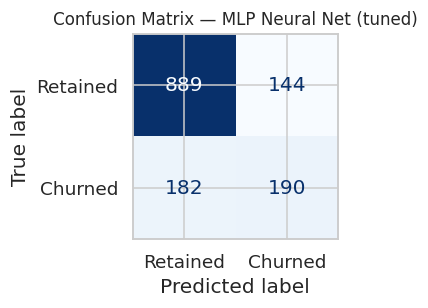

In [ ]:
# Multi-Layer Perceptron: captures complex non-linear patterns via hidden layers.
# Slower to train than tree ensembles but can learn feature interactions.
# alpha = L2 regularisation to prevent overfitting on the SMOTE-inflated training set.
mlp_params = {
    'hidden_layer_sizes': [(128, 64), (128, 64, 32)],
    'alpha'             : [1e-4, 1e-3],
    'learning_rate_init': [1e-3, 5e-4],
    'batch_size'        : [64, 128]
}
mlp_cv = GridSearchCV(
    MLPClassifier(max_iter=300, early_stopping=True, random_state=RANDOM_STATE),
    mlp_params, cv=5, scoring='recall', n_jobs=-1, verbose=0
)
mlp_cv.fit(X_train_res, y_train_res)
print('Best MLP params:', mlp_cv.best_params_)
best_mlp = mlp_cv.best_estimator_
res_mlp  = evaluate_model('MLP Neural Net (tuned)', best_mlp,
                           X_train_res, y_train_res, X_test_sc, y_test)

### 7.9 — Soft Voting Ensemble (LR + GB + XGB)


  Voting Ensemble (LR+GB+XGB)
              precision    recall  f1-score   support

    Retained       0.89      0.78      0.83      1033
     Churned       0.55      0.73      0.63       372

    accuracy                           0.77      1405
   macro avg       0.72      0.76      0.73      1405
weighted avg       0.80      0.77      0.78      1405

  Accuracy: 0.7680  |  Recall(churn): 0.7339  |  F1-macro: 0.7290


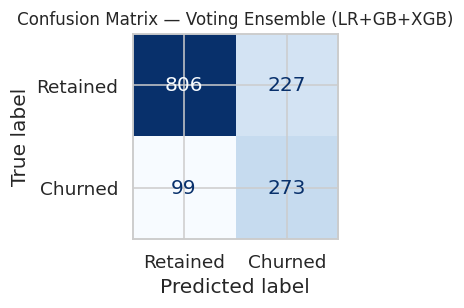

In [ ]:
# Voting Ensemble: averages predicted probabilities from diverse models.
# Combining a linear model (LR), a sequential booster (GB), and a parallel
# booster (XGB) often improves robustness by reducing each model's blind spots.
ensemble = VotingClassifier(
    estimators=[('lr', res_lr['fitted_model']),
                ('gb', best_gb),
                ('xgb', best_xgb)],
    voting='soft'
)
res_ens = evaluate_model('Voting Ensemble (LR+GB+XGB)', ensemble,
                          X_train_res, y_train_res, X_test_sc, y_test)

## Step 8 — Threshold Tuning
> Default 0.5 probability cutoff is not optimal when recall matters.
> We sweep thresholds on the best-AUC model and pick the one that maximises
> F1 for churners while keeping precision at an acceptable level.

Tuning threshold on: Voting Ensemble (LR+GB+XGB)  (ROC-AUC=0.8356)


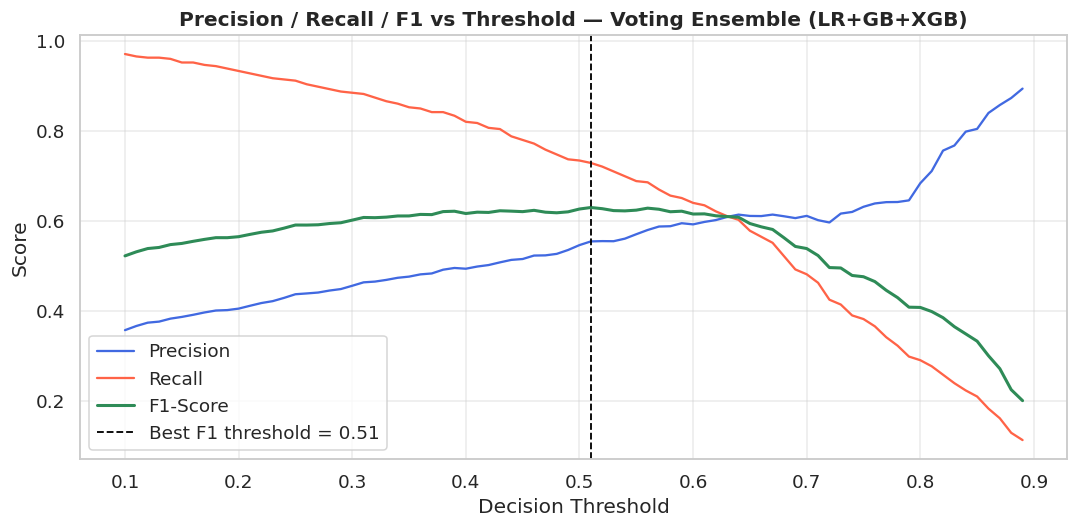

Optimal threshold by F1: 0.51


In [ ]:
# ── Identify the best-AUC model ───────────────────────────────────────────
best_result = max([r for r in results if r['roc_auc'] is not None],
                   key=lambda r: r['roc_auc'])
best_name  = best_result['model']
best_probs = best_result['y_prob']
print(f'Tuning threshold on: {best_name}  (ROC-AUC={best_result["roc_auc"]:.4f})')

# ── Sweep thresholds 0.1 → 0.9, record precision, recall, F1 ─────────────
thresholds = np.arange(0.10, 0.90, 0.01)
prec_list, rec_list, f1_list = [], [], []

for t in thresholds:
    y_t = (best_probs >= t).astype(int)
    rep = classification_report(y_test, y_t, output_dict=True, zero_division=0)
    prec_list.append(rep['1']['precision'])
    rec_list.append(rep['1']['recall'])
    f1_list.append(rep['1']['f1-score'])

# ── Plot the threshold curve ───────────────────────────────────────────────
# WHY: The intersection of precision and recall curves + the F1 peak guide
#      the final threshold choice. Move left = catch more churners (higher recall,
#      lower precision = more false alarms). Move right = fewer alerts but miss more churners.

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, prec_list, label='Precision', color='royalblue')
ax.plot(thresholds, rec_list,  label='Recall',    color='tomato')
ax.plot(thresholds, f1_list,   label='F1-Score',  color='seagreen', linewidth=2)

best_t = thresholds[np.argmax(f1_list)]
ax.axvline(best_t, color='black', linestyle='--', linewidth=1.2,
           label=f'Best F1 threshold = {best_t:.2f}')
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Score')
ax.set_title(f'Precision / Recall / F1 vs Threshold — {best_name}', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print(f'Optimal threshold by F1: {best_t:.2f}')

>>> Evaluation at threshold = 0.51  (Voting Ensemble (LR+GB+XGB))
              precision    recall  f1-score   support

    Retained       0.89      0.79      0.84      1033
     Churned       0.55      0.73      0.63       372

    accuracy                           0.77      1405
   macro avg       0.72      0.76      0.73      1405
weighted avg       0.80      0.77      0.78      1405



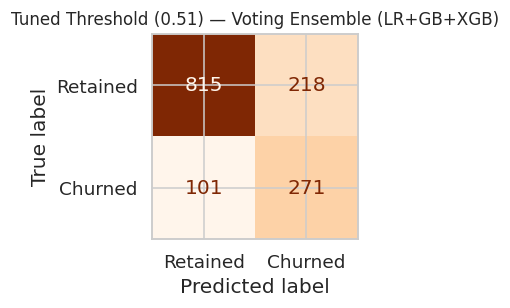

In [ ]:
# ── Apply tuned threshold and print final report ──────────────────────────
TUNED_THRESHOLD = best_t
y_pred_tuned = (best_probs >= TUNED_THRESHOLD).astype(int)

print(f'>>> Evaluation at threshold = {TUNED_THRESHOLD:.2f}  ({best_name})')
print(classification_report(y_test, y_pred_tuned, target_names=['Retained', 'Churned']))

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned, display_labels=['Retained', 'Churned'],
    colorbar=False, ax=ax, cmap='Oranges'
)
ax.set_title(f'Tuned Threshold ({TUNED_THRESHOLD:.2f}) — {best_name}', fontsize=11)
plt.tight_layout()
plt.show()

## Step 9 — Final Model Comparison & Recommendation
> Summarise all models in one table and visualise Recall vs Accuracy trade-off.
> Then display feature importances from the best tree-based model.

In [ ]:
# ── Summary table sorted by recall_churn ──────────────────────────────────
# WHY: Sorting by recall shows which models catch the most churners.
#      We also show accuracy and ROC-AUC so stakeholders can assess
#      the trade-off between sensitivity and overall correctness.

summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('fitted_model', 'y_prob')}
    for r in results
])
summary = (summary
           .sort_values('recall_churn', ascending=False)
           .reset_index(drop=True))
summary[['accuracy', 'f1_macro', 'recall_churn', 'roc_auc']] = \
    summary[['accuracy', 'f1_macro', 'recall_churn', 'roc_auc']].round(4)
display(summary)

,model,accuracy,f1_macro,recall_churn,roc_auc
0,KNN (tuned),0.7139,0.6914,0.8387,0.8222
1,XGBoost (tuned),0.7203,0.6945,0.8118,0.8304
2,Voting Ensemble (LR+GB+XGB),0.7680,0.7290,0.7339,0.8356
3,Random Forest (tuned),0.7673,0.7283,0.7339,0.8346
4,Gradient Boosting (tuned),0.7708,0.7281,0.7070,0.8345
5,Decision Tree (tuned),0.7416,0.6984,0.6855,0.7828
6,Logistic Regression,0.7808,0.7284,0.6452,0.8334
7,SVM (RBF),0.7829,0.7215,0.5914,0.8036
8,MLP Neural Net (tuned),0.7680,0.6917,0.5108,0.8100


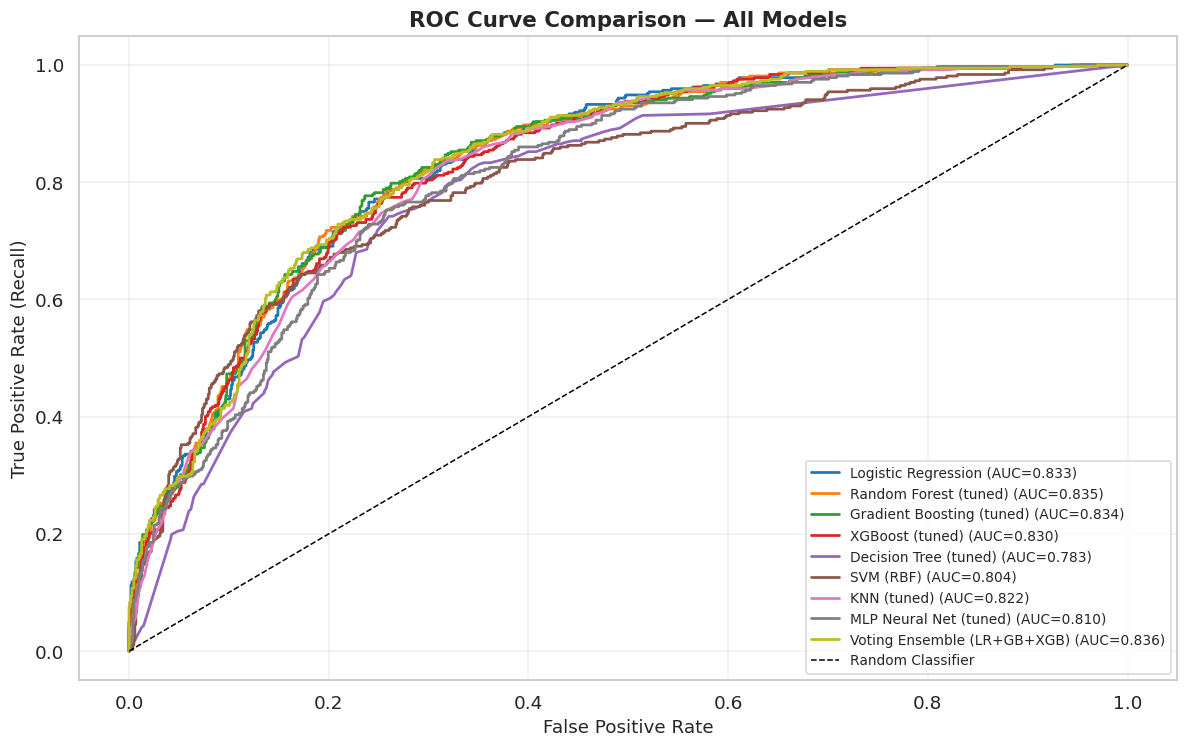

In [ ]:
# ── ROC curves for all models ──────────────────────────────────────────────
# WHY: ROC curve plots TPR vs FPR at every possible threshold.
#      AUC = probability that the model ranks a churner higher than a non-churner.
#      A model that hugs the top-left corner is ideal.

fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.tab10.colors

for i, r in enumerate(results):
    if r['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
        ax.plot(fpr, tpr, color=colors[i % 10], linewidth=1.8,
                label=f"{r['model']} (AUC={r['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve Comparison — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

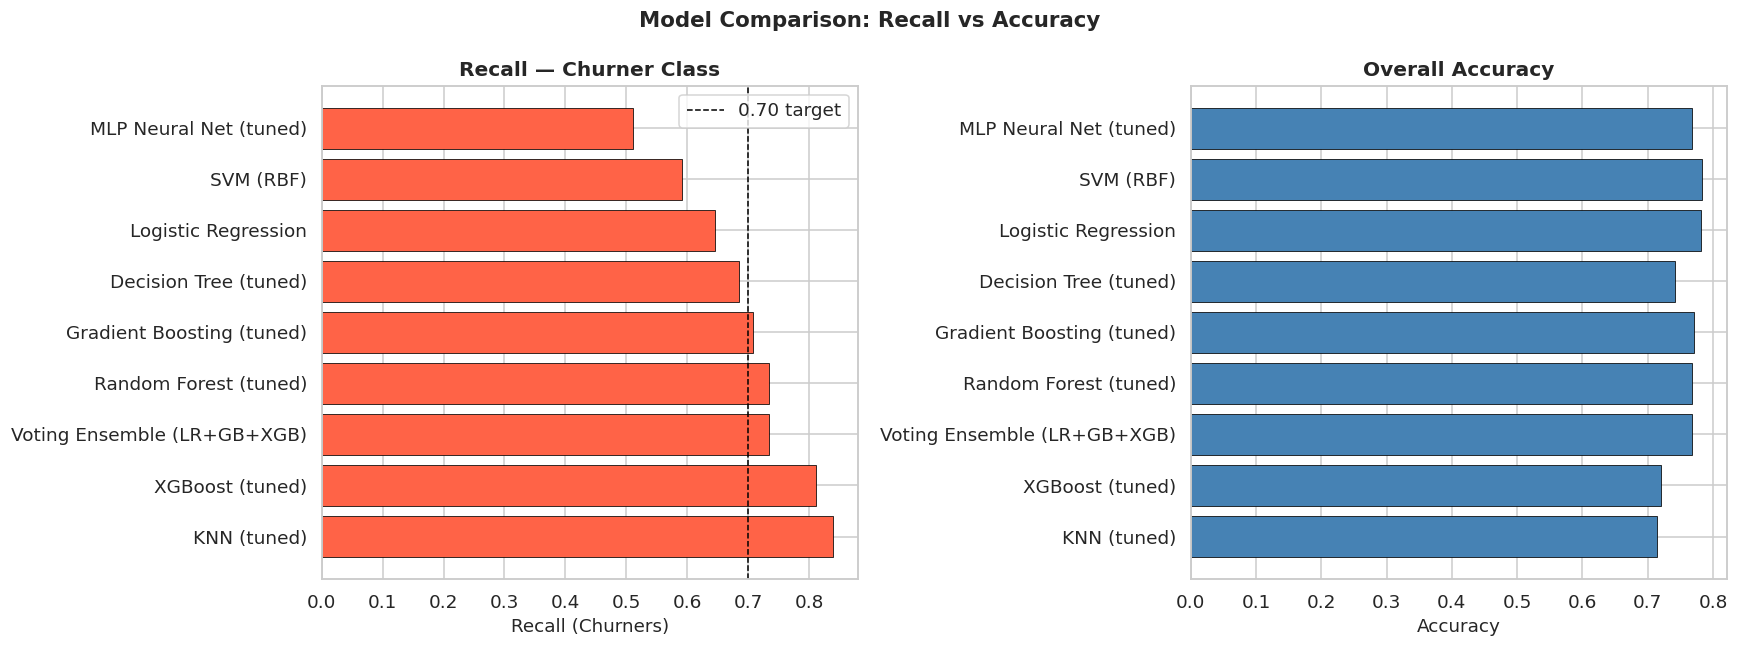

In [ ]:
# ── Bar chart: Recall vs Accuracy side-by-side ────────────────────────────
# WHY: Side-by-side bars make the recall–accuracy trade-off immediately visible.
#      Models with high recall but lower accuracy sacrifice some overall correctness
#      to catch more churners — often the right business decision.

names = summary['model'].tolist()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(names, summary['recall_churn'], color='tomato', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Recall (Churners)', fontsize=12)
axes[0].set_title('Recall — Churner Class', fontweight='bold')
axes[0].axvline(0.7, color='black', linestyle='--', linewidth=1, label='0.70 target')
axes[0].legend()

axes[1].barh(names, summary['accuracy'], color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Accuracy', fontsize=12)
axes[1].set_title('Overall Accuracy', fontweight='bold')

plt.suptitle('Model Comparison: Recall vs Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

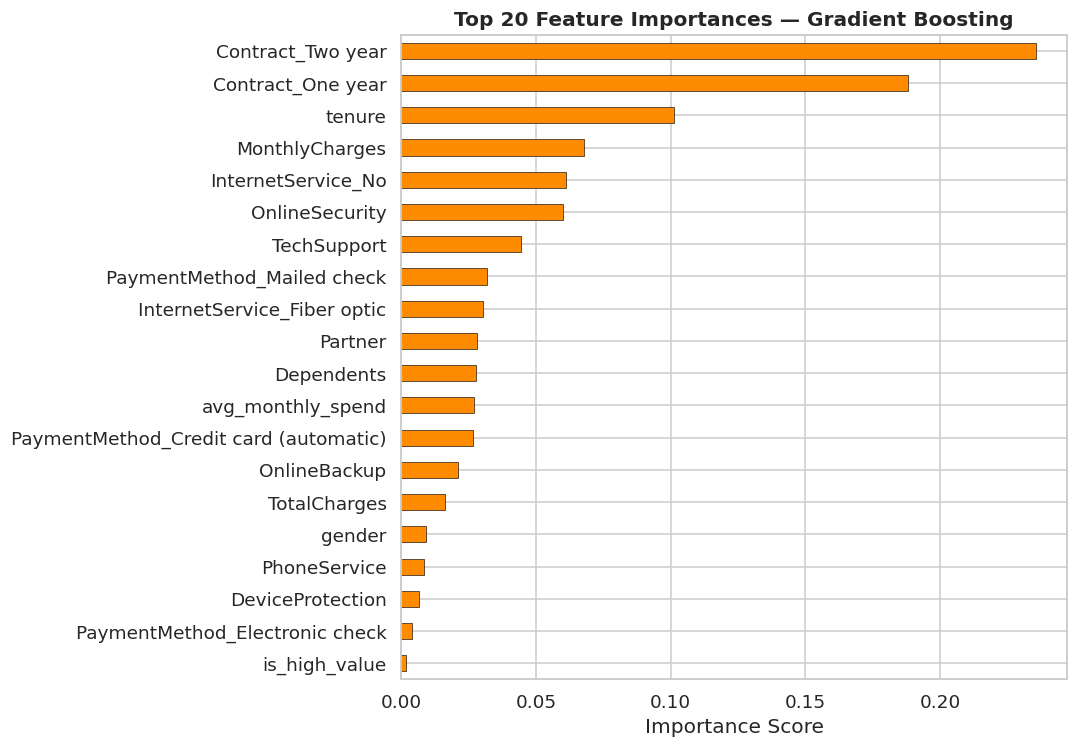

In [ ]:
# ── Feature importance from best tree-based model ─────────────────────────
# WHY: Feature importances show which signals drive churn predictions most.
#      This is the bridge between ML output and business action:
#      'tenure is #1 → focus retention efforts on new customers.'

try:
    fi_model = best_gb  # Gradient Boosting provides clean, stable importances
    fi = pd.Series(fi_model.feature_importances_, index=X.columns)
    fi = fi.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    fi.sort_values().plot(kind='barh', ax=ax, color='darkorange', edgecolor='black', linewidth=0.4)
    ax.set_title('Top 20 Feature Importances — Gradient Boosting', fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Feature importance unavailable: {e}')

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FINAL RECOMMENDATION
# ════════════════════════════════════════════════════════════════════════════
best_row = summary.iloc[0]
print('\n' + '='*60)
print('  FINAL RECOMMENDATION')
print('='*60)
print(f'  Best model (by Recall): {best_row["model"]}')
print(f'  Recall  (Churn) : {best_row["recall_churn"]:.4f}')
print(f'  ROC-AUC         : {best_row["roc_auc"]:.4f}')
print(f'  Accuracy        : {best_row["accuracy"]:.4f}')
print(f'  F1 (macro)      : {best_row["f1_macro"]:.4f}')
print('='*60)
print(f'\n  Recommended threshold : {TUNED_THRESHOLD:.2f}  (optimised for F1-churn)')
print('\n  Business insight:')
print('  → Focus retention on customers with tenure < 12 months')
print('  → Month-to-month contracts are the highest-risk segment')
print('  → High MonthlyCharges with no add-on services = strong churn signal')
print('='*60)


  FINAL RECOMMENDATION
  Best model (by Recall): KNN (tuned)
  Recall  (Churn) : 0.8387
  ROC-AUC         : 0.8222
  Accuracy        : 0.7139
  F1 (macro)      : 0.6914

  Recommended threshold : 0.51  (optimised for F1-churn)

  Business insight:
  → Focus retention on customers with tenure < 12 months
  → Month-to-month contracts are the highest-risk segment
  → High MonthlyCharges with no add-on services = strong churn signal


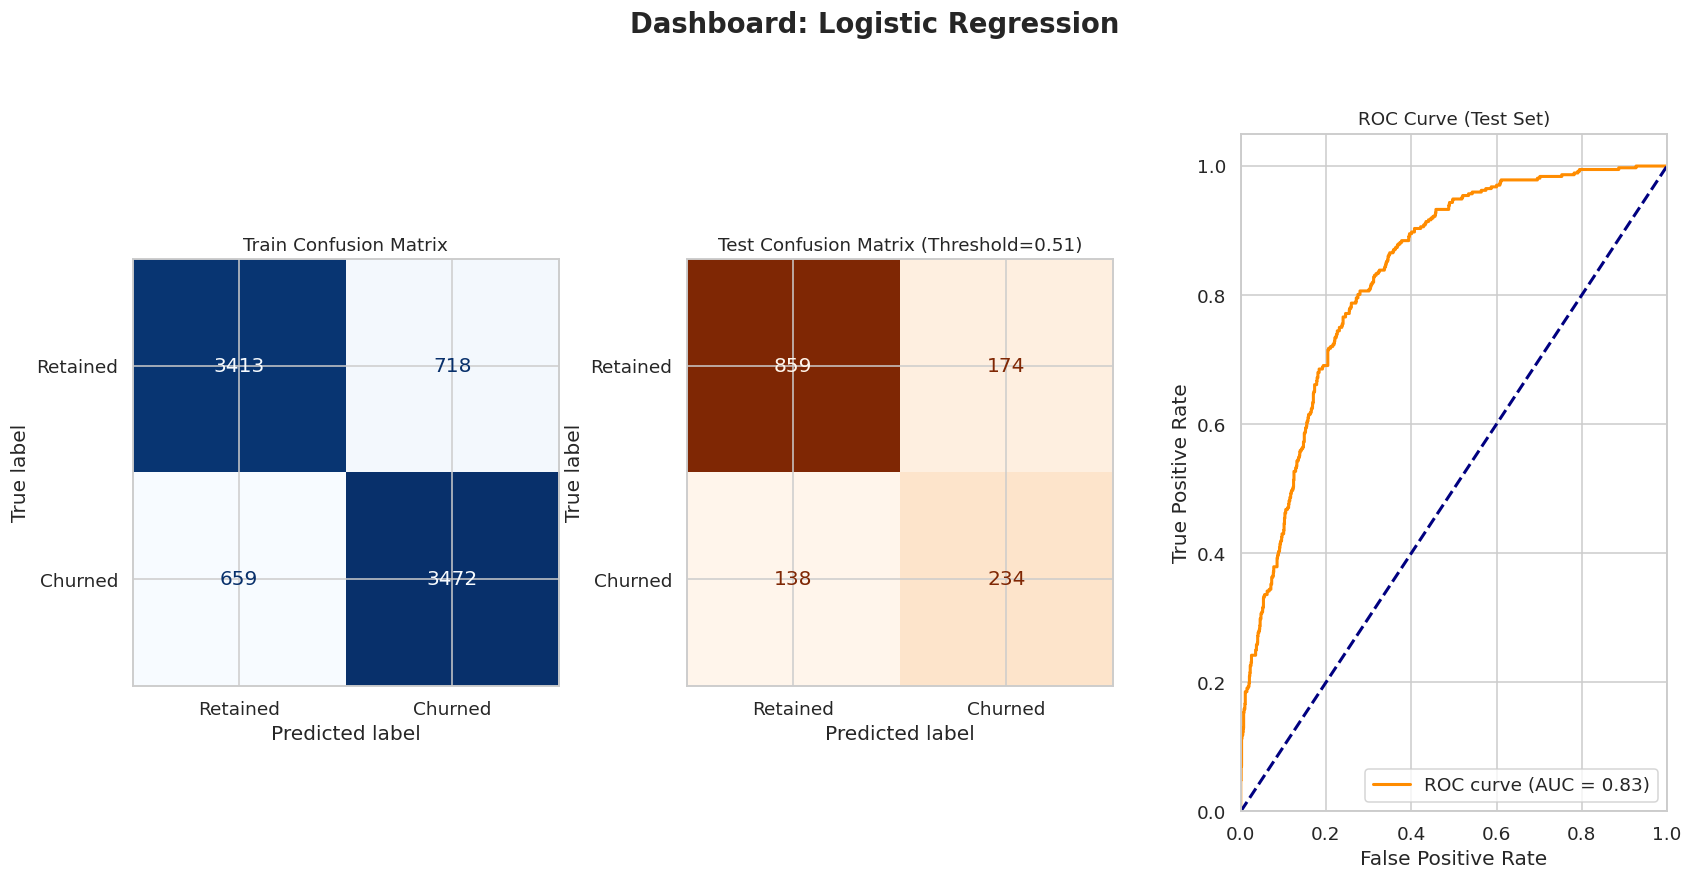

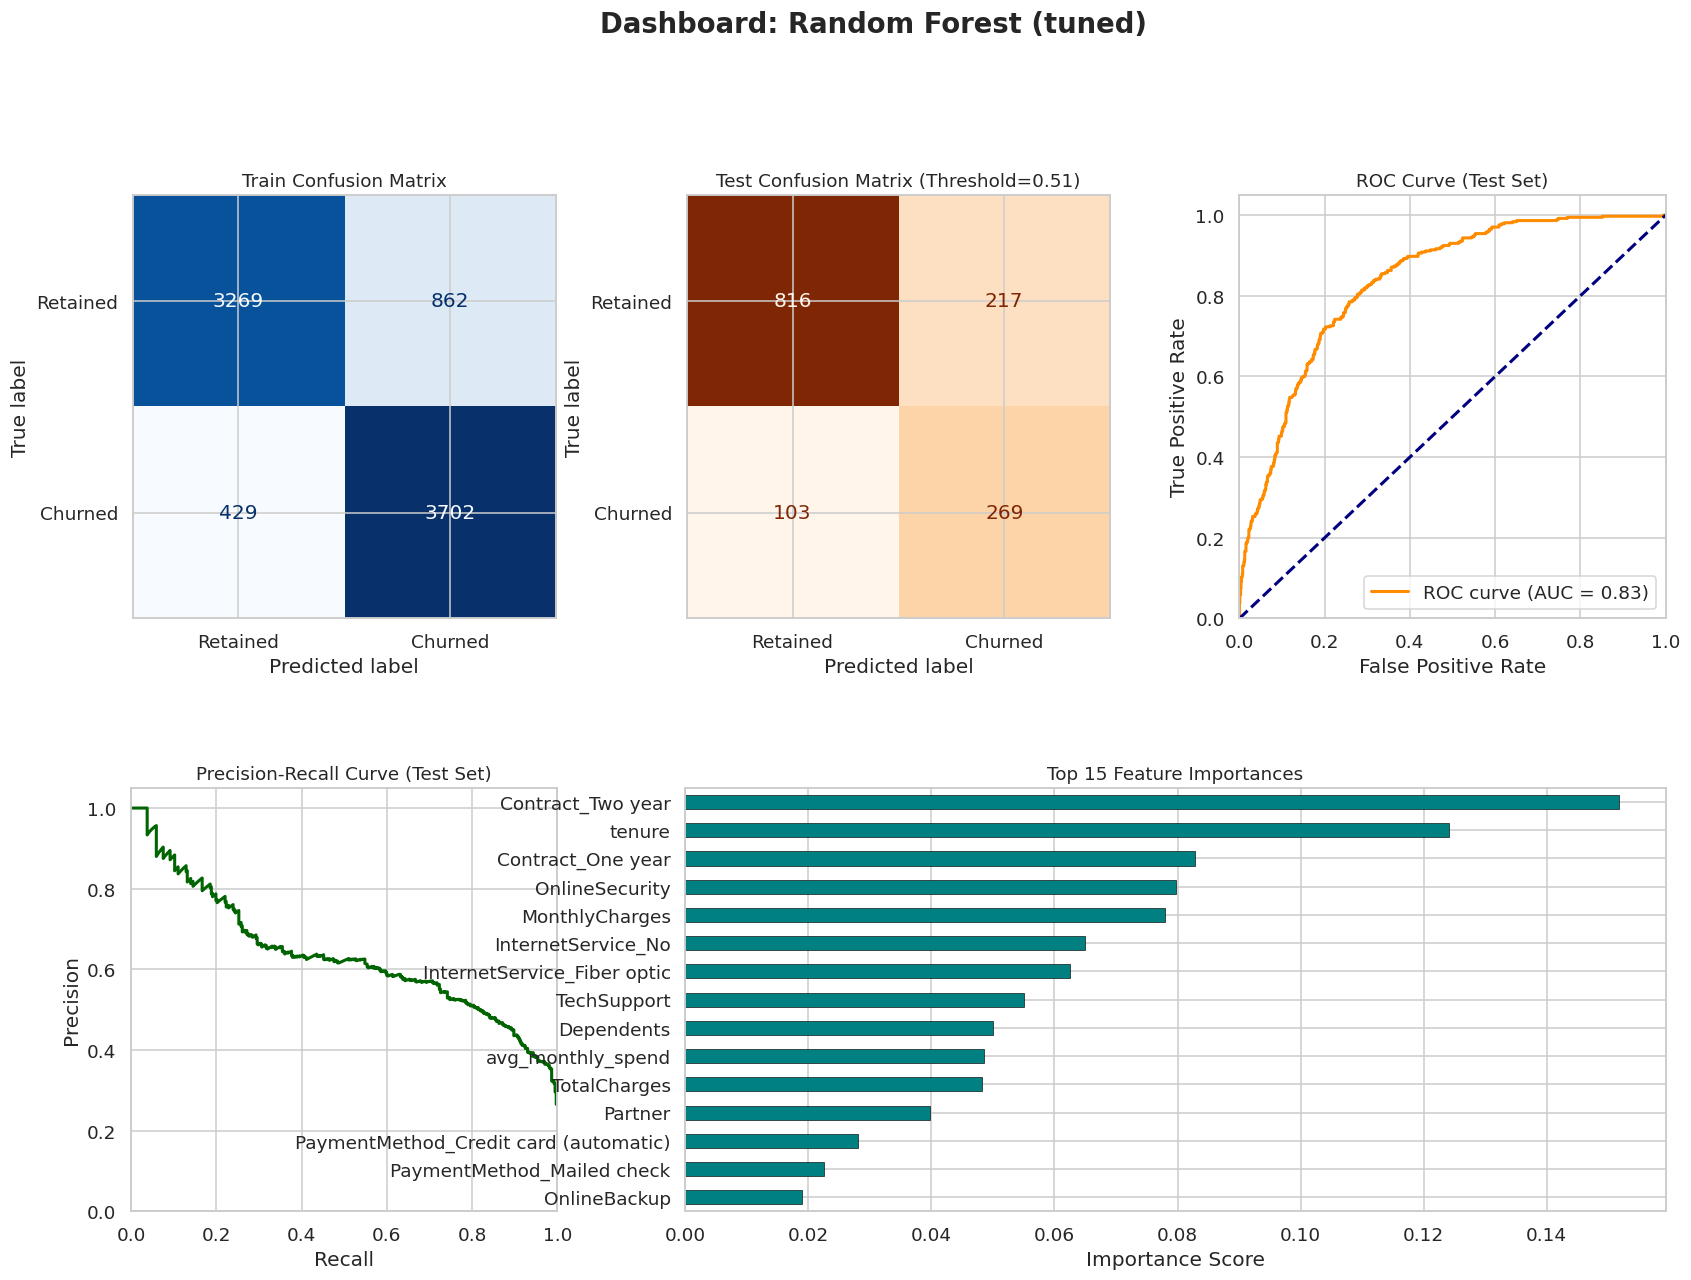

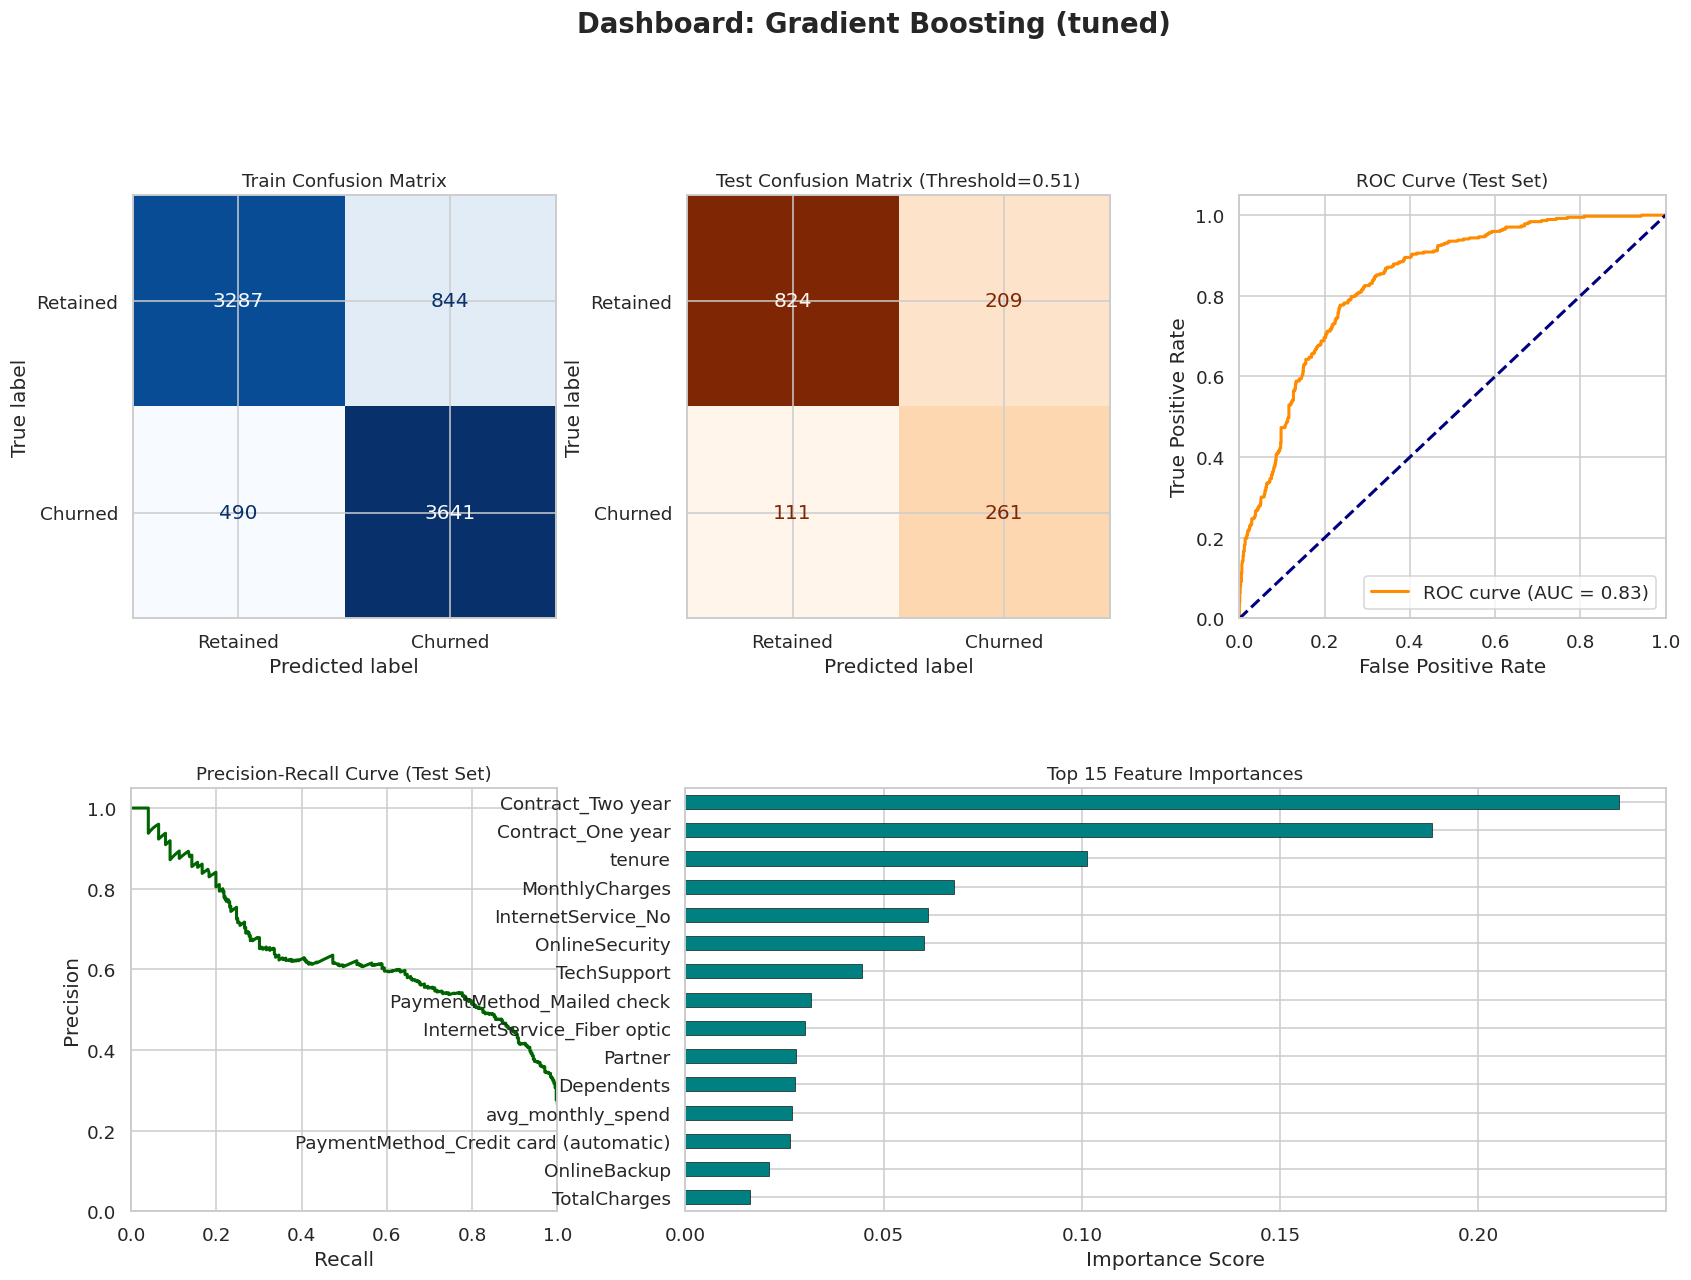

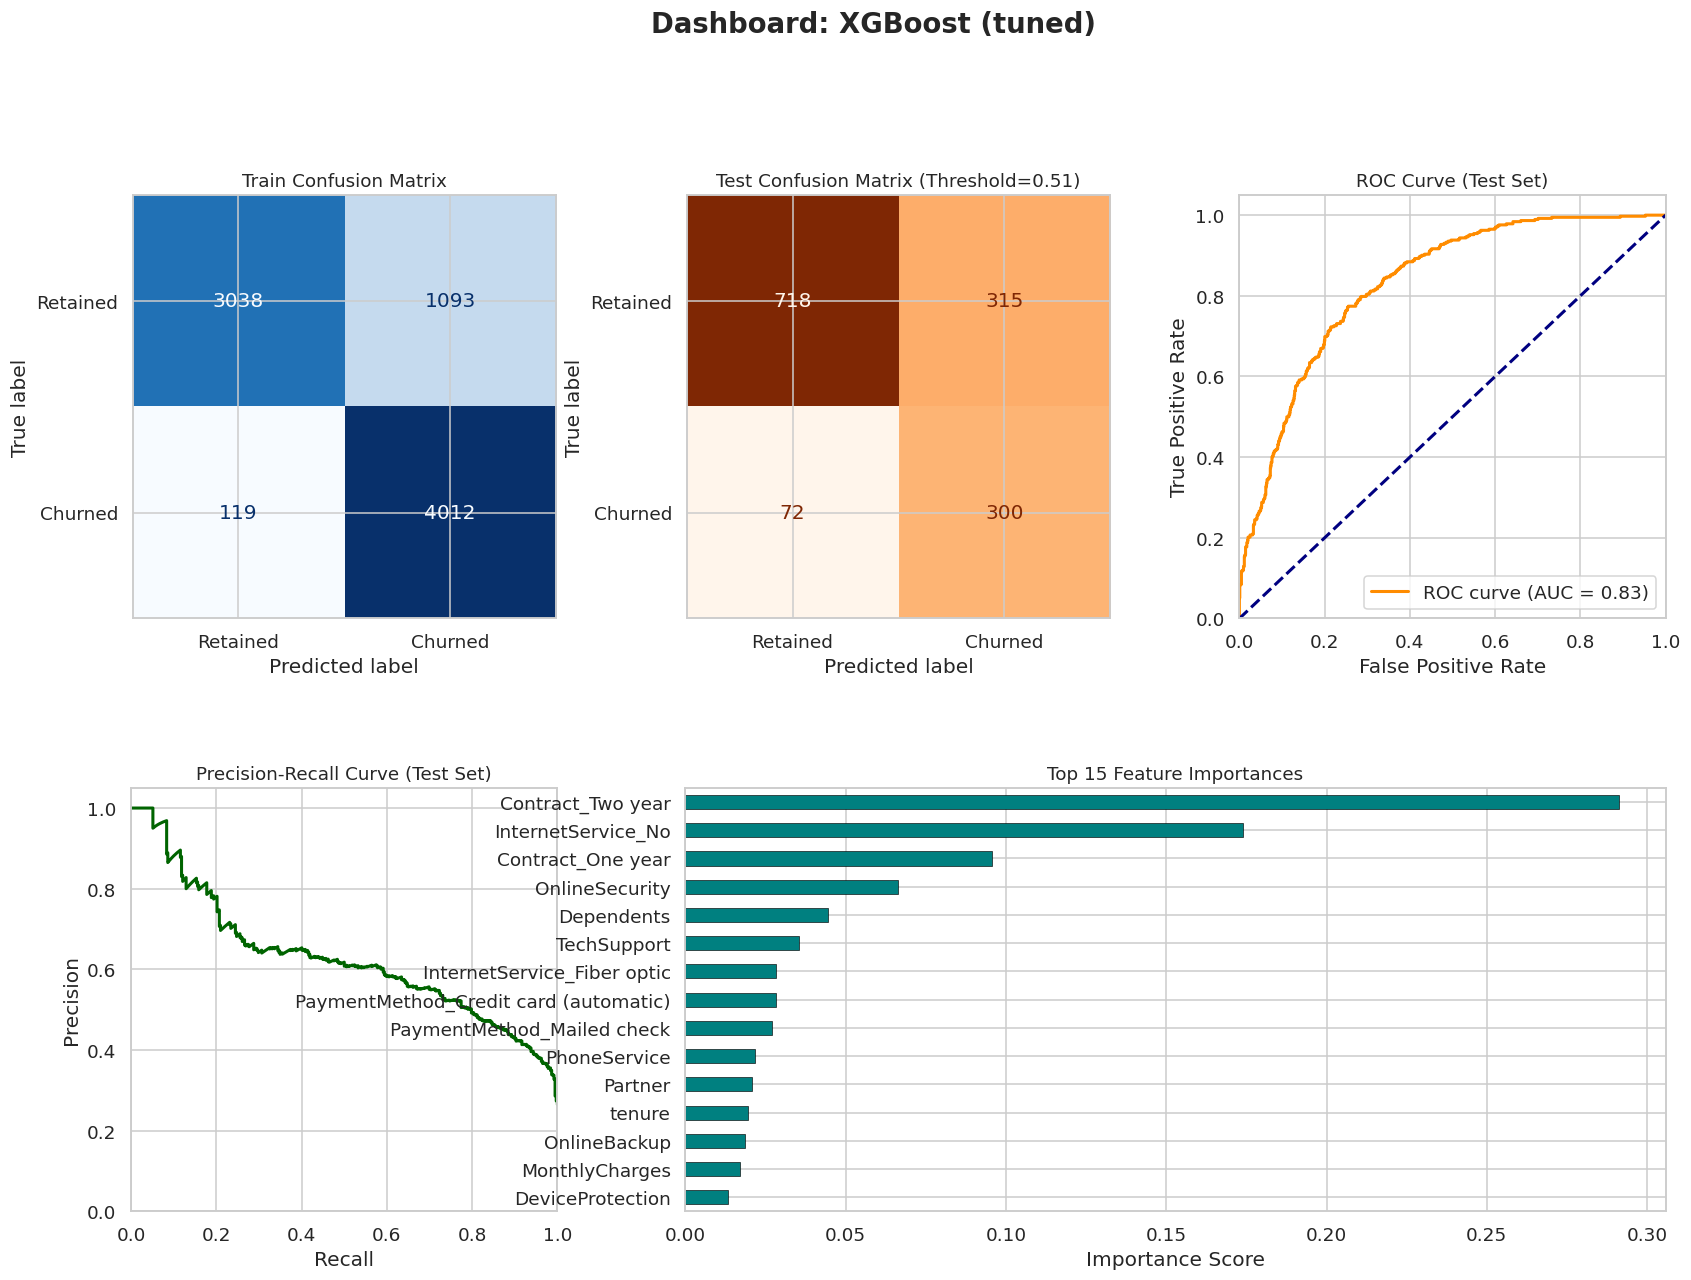

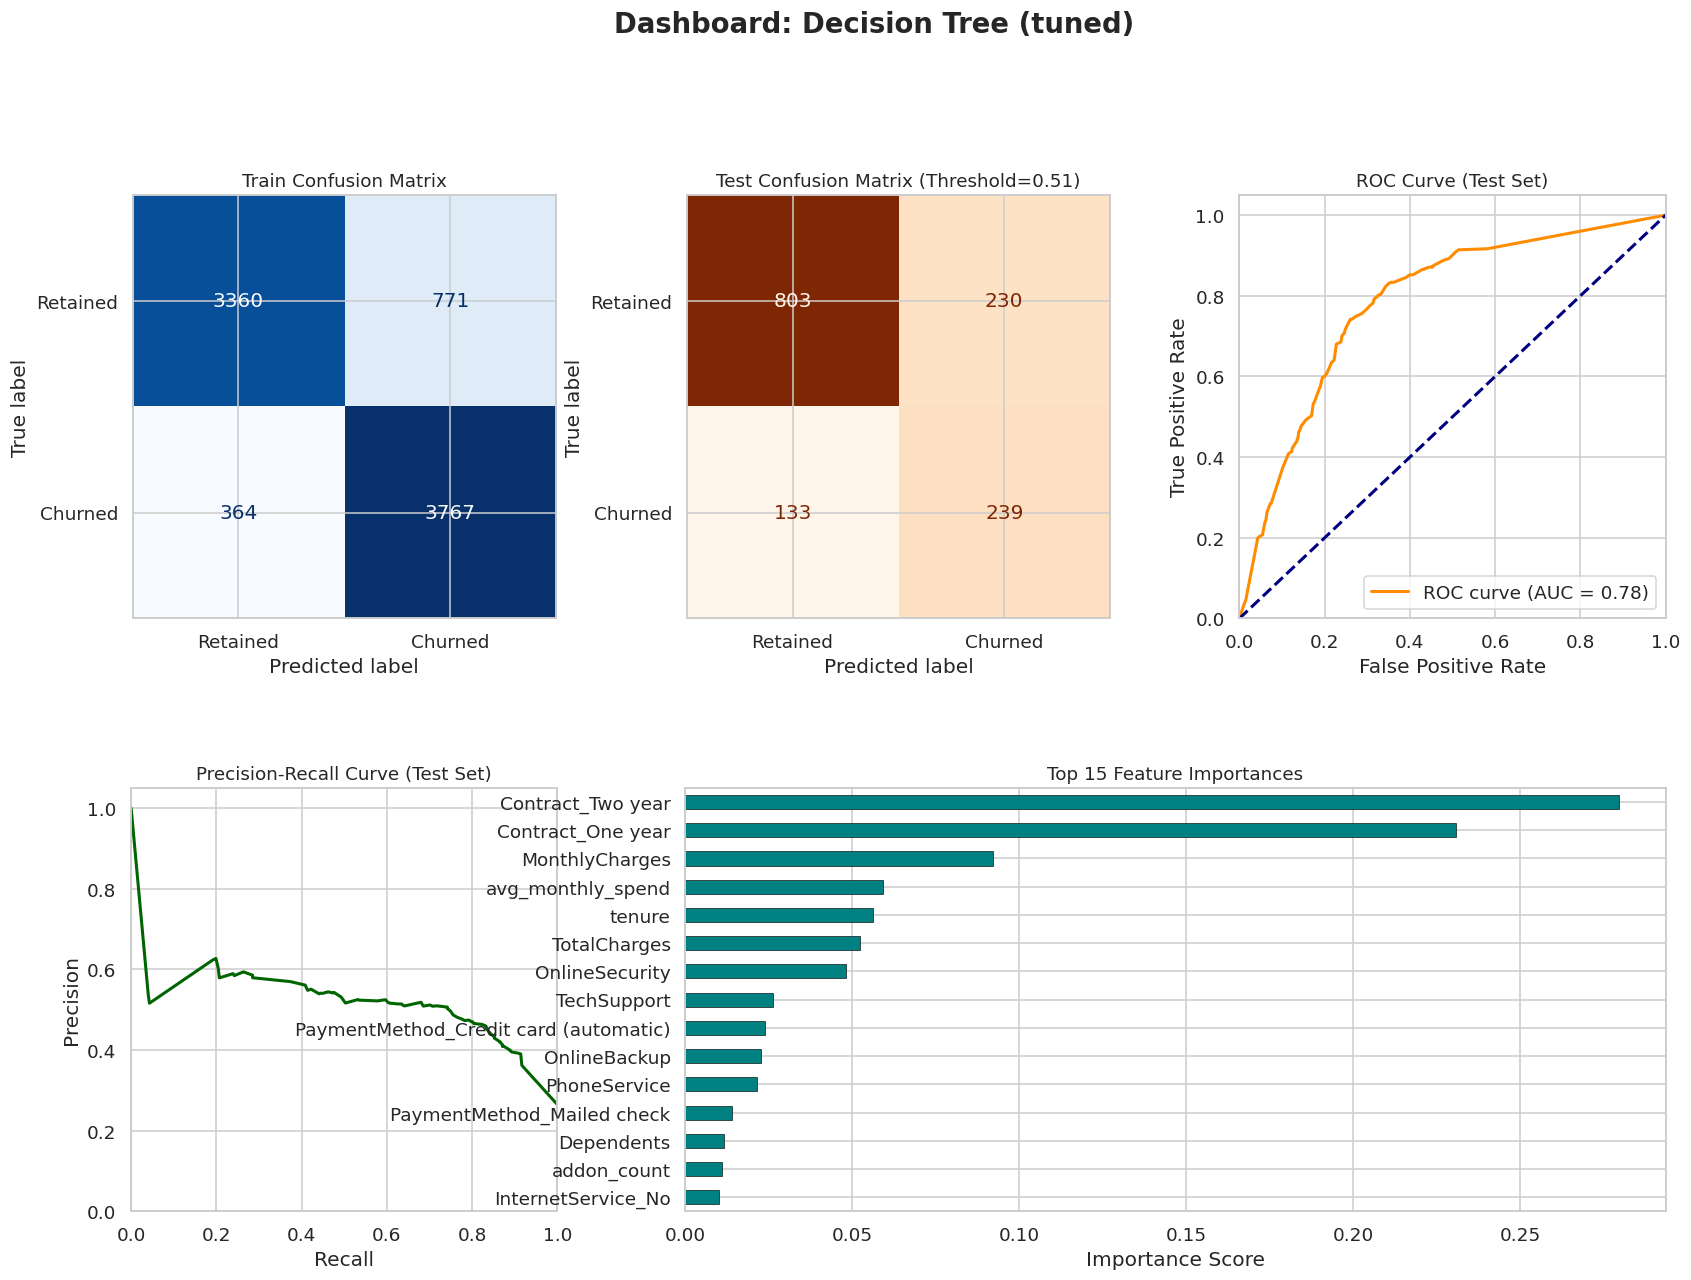

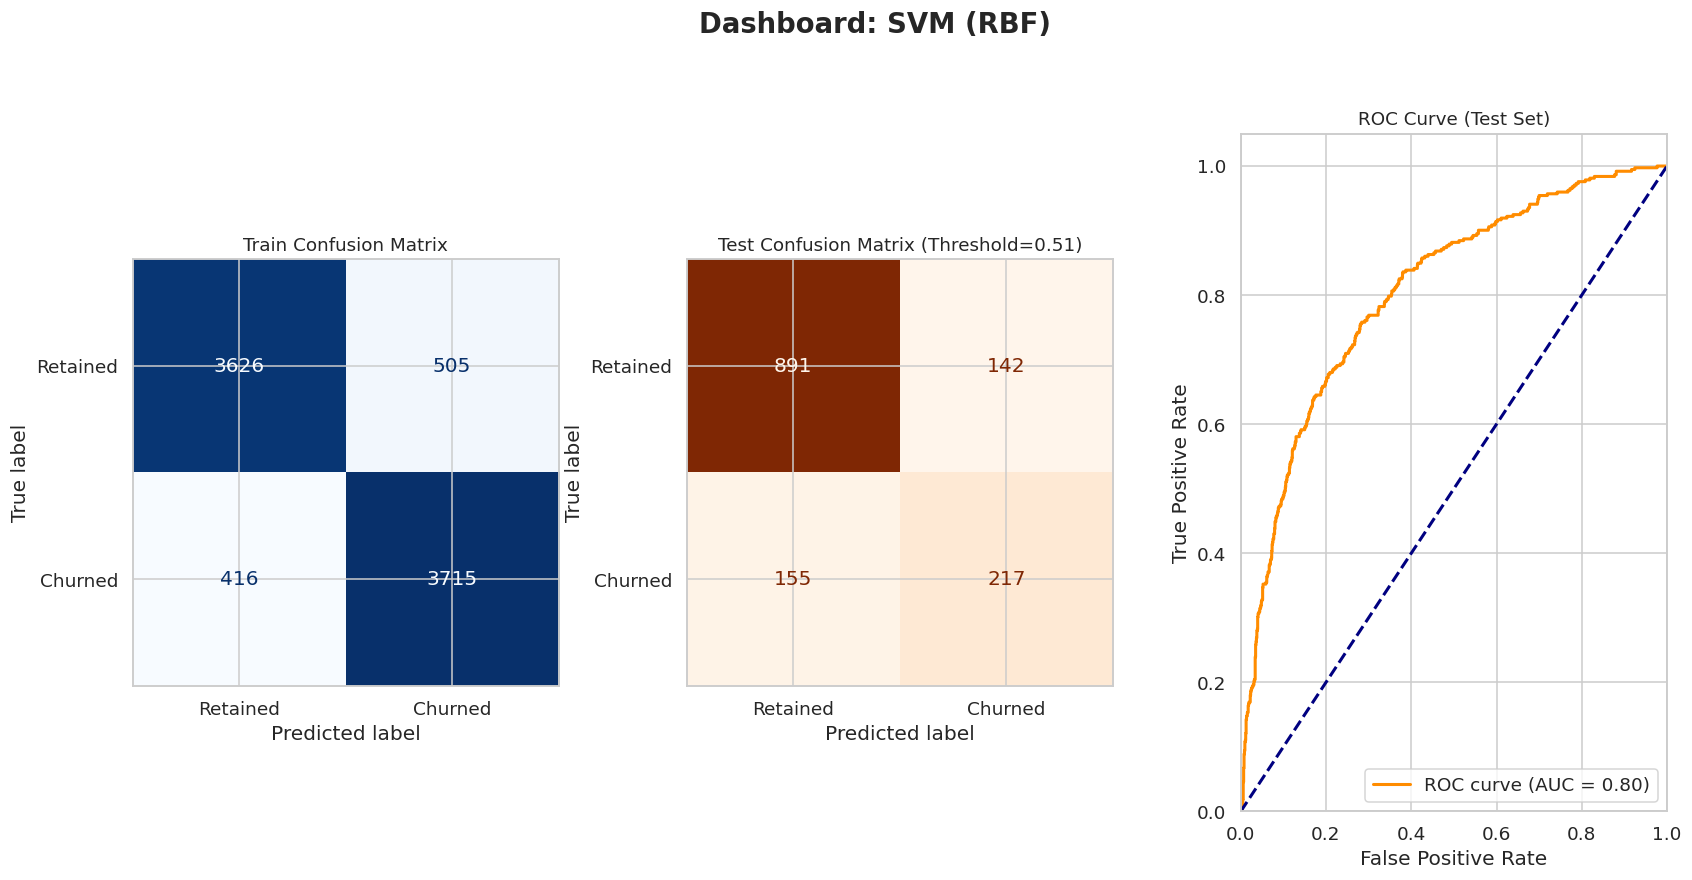

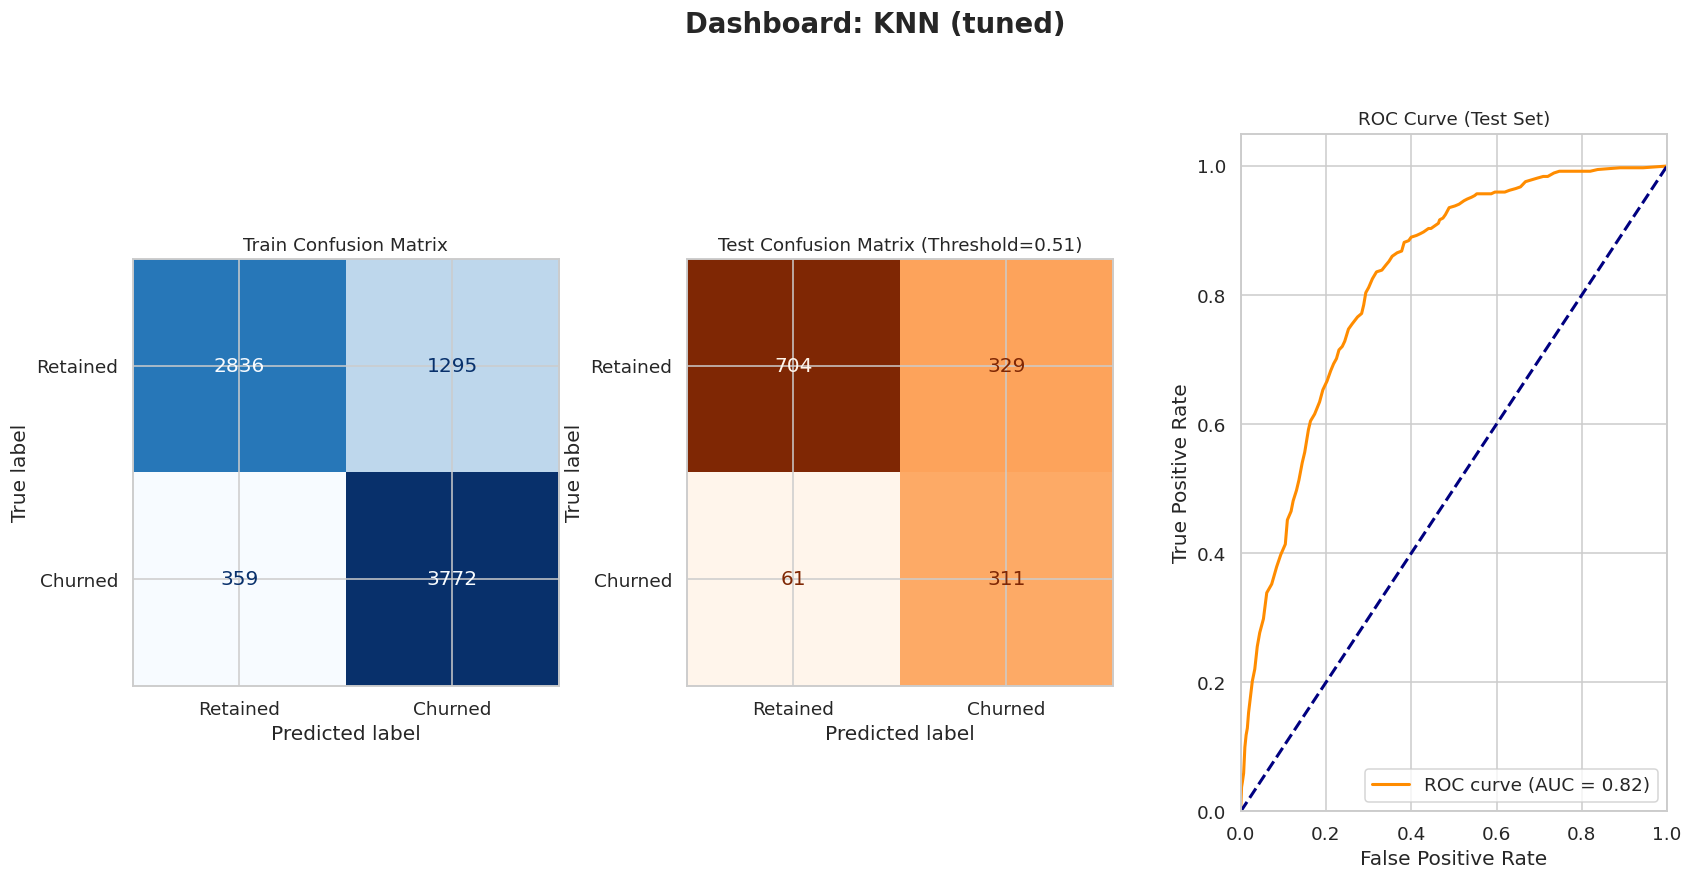

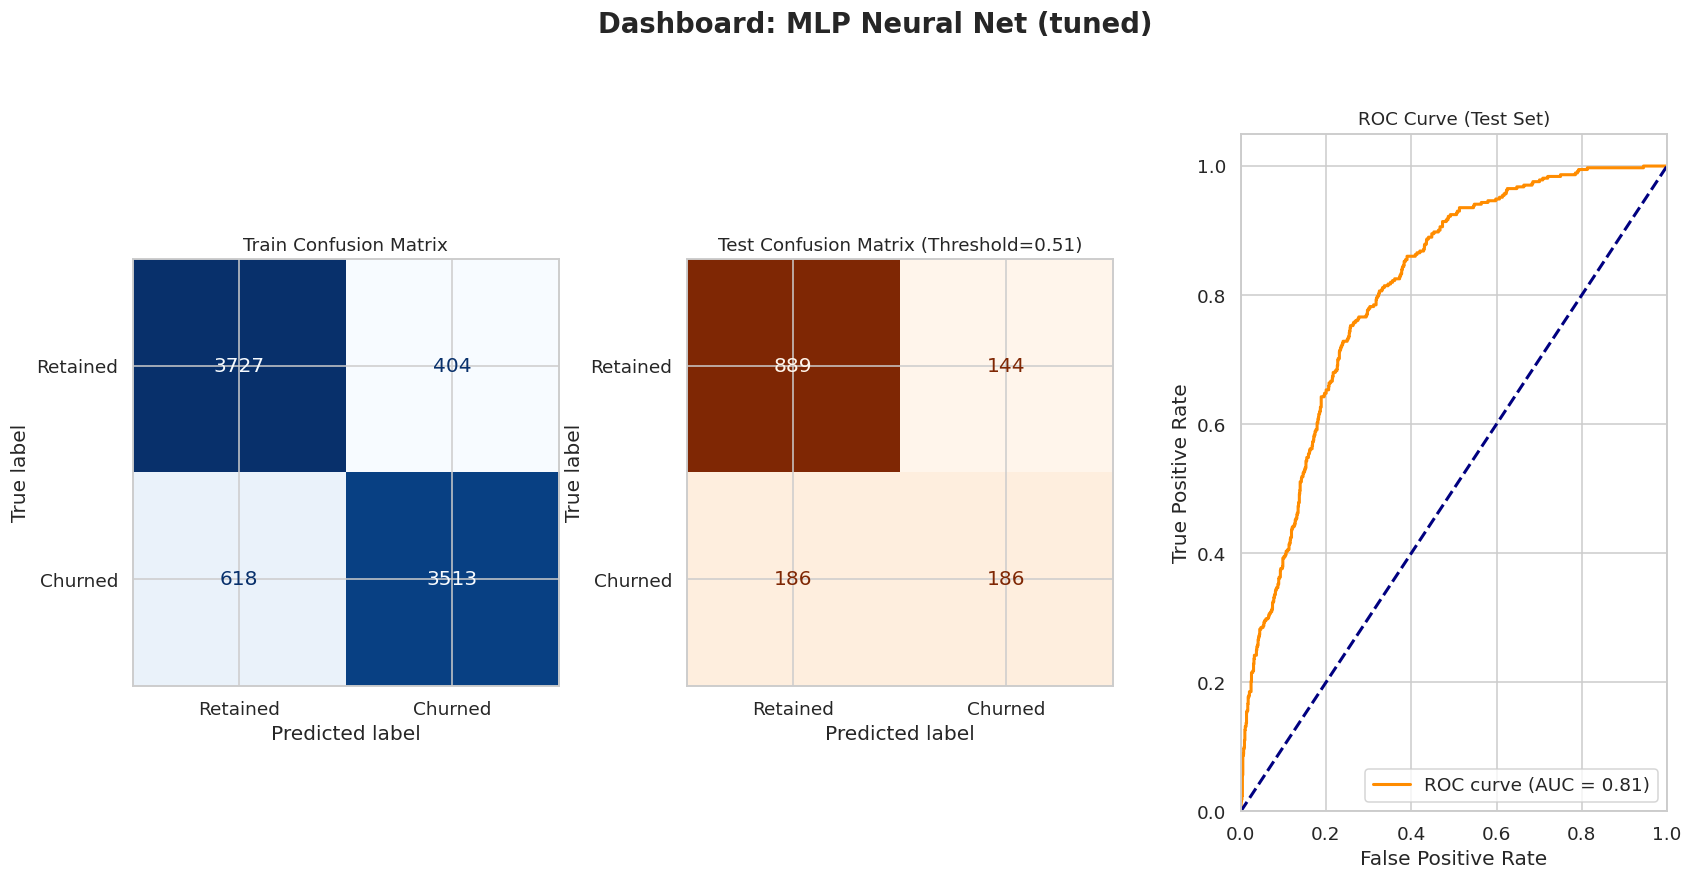

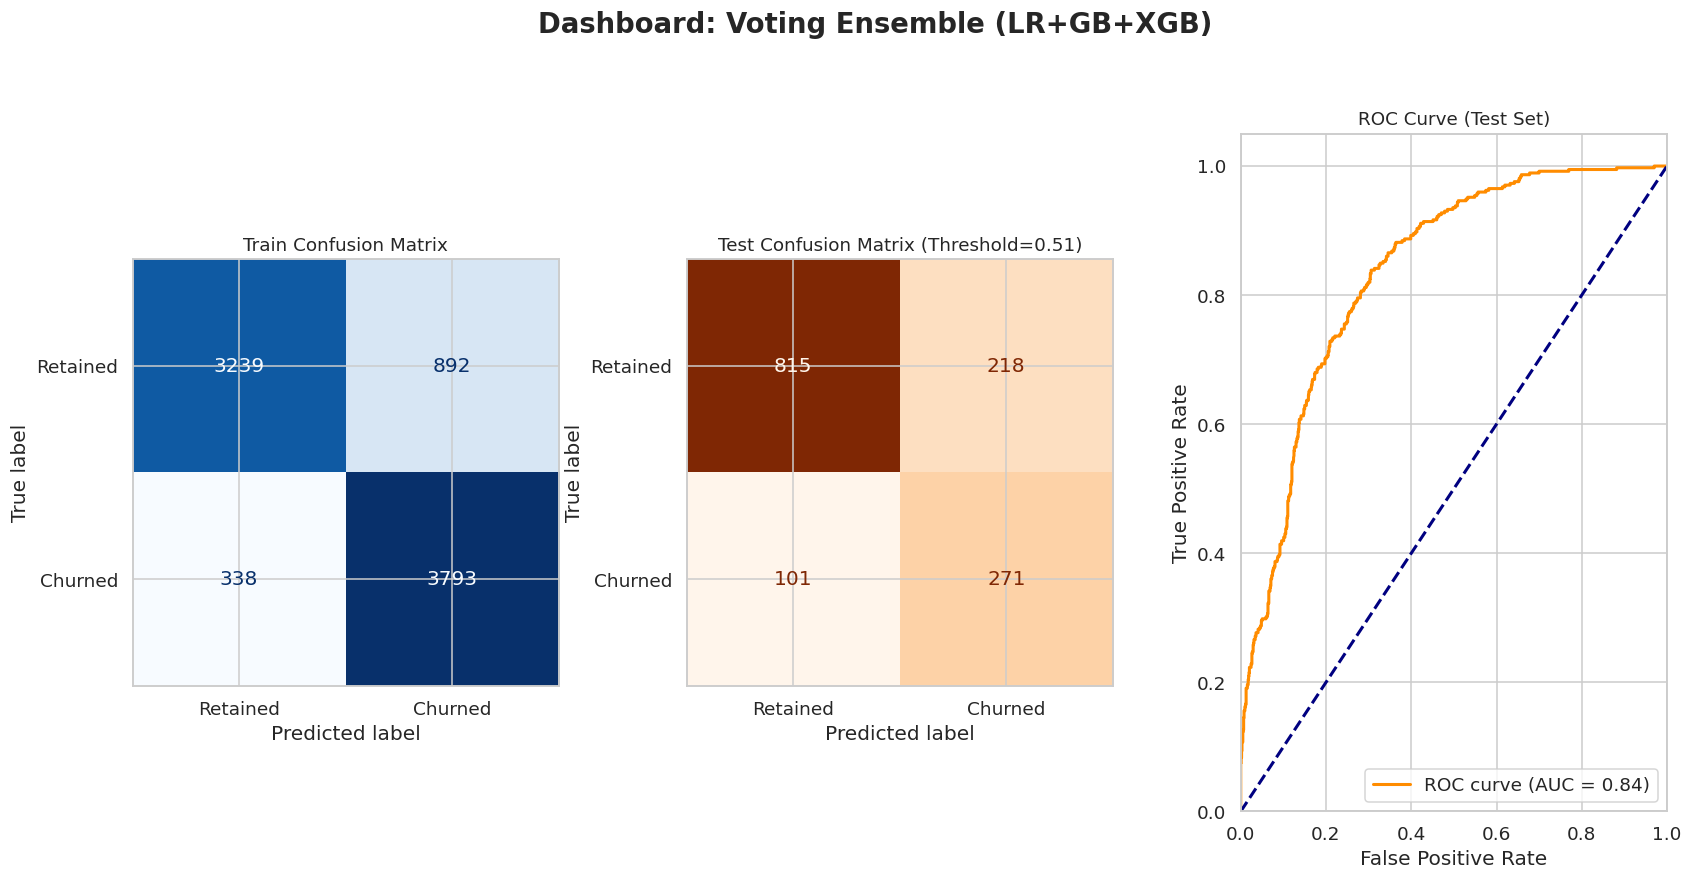

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, roc_auc_score
import numpy as np
import pandas as pd

def display_model_dashboard(model_result, X_train, y_train, X_test, y_test, X_original_cols, global_tuned_threshold=0.5):
    """
    Generates and displays a dashboard for a given model, including:
    - Confusion Matrix for the training set
    - Confusion Matrix for the test set (using a specified threshold)
    - ROC Curve for the test set
    - Precision-Recall Curve for the test set
    - Feature Importances (if applicable for the model type)
    """
    model_name = model_result['model']
    fitted_model = model_result['fitted_model']
    y_prob_test = model_result.get('y_prob') # Use .get to handle models without predict_proba

    # Determine if feature importances are available and retrieve them
    has_feature_importances = False
    feature_importances = None
    feature_names = X_original_cols.columns.tolist()

    if hasattr(fitted_model, 'feature_importances_'):
        feature_importances = fitted_model.feature_importances_
        has_feature_importances = True
    elif hasattr(fitted_model, 'coef_') and len(fitted_model.coef_.shape) == 1: # For binary classification linear models
        feature_importances = np.abs(fitted_model.coef_) # Magnitude of coefficients
        has_feature_importances = True

    # Setup figure and gridspec based on presence of feature importances
    if has_feature_importances:
        fig = plt.figure(figsize=(18, 12))
        gs = gridspec.GridSpec(nrows=2, ncols=3, figure=fig, hspace=0.4, wspace=0.3)
    else:
        # If no feature importances, we can still show PR curve and other metrics
        fig = plt.figure(figsize=(18, 8))
        gs = gridspec.GridSpec(nrows=1, ncols=3, figure=fig, hspace=0.4, wspace=0.3)

    fig.suptitle(f'Dashboard: {model_name}', fontsize=18, fontweight='bold', y=1.02)

    # --- 1. Train Confusion Matrix ---
    ax0 = fig.add_subplot(gs[0, 0])
    y_pred_train = fitted_model.predict(X_train)
    cm_train = confusion_matrix(y_train, y_pred_train)
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Retained', 'Churned'])
    disp_train.plot(cmap='Blues', ax=ax0, colorbar=False)
    ax0.set_title('Train Confusion Matrix', fontsize=12)

    # --- 2. Test Confusion Matrix ---
    ax1 = fig.add_subplot(gs[0, 1])
    if y_prob_test is not None:
        y_pred_test = (y_prob_test >= global_tuned_threshold).astype(int)
    else:
        y_pred_test = fitted_model.predict(X_test) # Fallback if no predict_proba (e.g., some SVM setups)
    cm_test = confusion_matrix(y_test, y_pred_test)
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Retained', 'Churned'])
    disp_test.plot(cmap='Oranges', ax=ax1, colorbar=False)
    ax1.set_title(f'Test Confusion Matrix (Threshold={global_tuned_threshold:.2f})', fontsize=12)

    # --- 3. ROC Curve (Test) ---
    ax2 = fig.add_subplot(gs[0, 2])
    if y_prob_test is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob_test)
        roc_auc_val = model_result.get('roc_auc')
        if roc_auc_val is None: # Calculate if not already in results
            roc_auc_val = roc_auc_score(y_test, y_prob_test)
        ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.2f})')
        ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax2.set_xlim([0.0, 1.0]); ax2.set_ylim([0.0, 1.05])
        ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
        ax2.set_title('ROC Curve (Test Set)', fontsize=12)
        ax2.legend(loc="lower right")
    else:
        ax2.text(0.5, 0.5, 'ROC Curve N/A (no predict_proba)', horizontalalignment='center',
                 verticalalignment='center', transform=ax2.transAxes, fontsize=10, color='gray')
        ax2.set_title('ROC Curve (Test Set)', fontsize=12)

    # --- Conditional plots for second row ---
    if has_feature_importances:
        # --- 4. Precision-Recall Curve (Test) ---
        ax3 = fig.add_subplot(gs[1, 0])
        if y_prob_test is not None:
            precision, recall, _ = precision_recall_curve(y_test, y_prob_test)
            ax3.plot(recall, precision, color='darkgreen', lw=2)
            ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
            ax3.set_title('Precision-Recall Curve (Test Set)', fontsize=12)
            ax3.set_xlim([0.0, 1.0]); ax3.set_ylim([0.0, 1.05])
        else:
            ax3.text(0.5, 0.5, 'PR Curve N/A (no predict_proba)', horizontalalignment='center',
                     verticalalignment='center', transform=ax3.transAxes, fontsize=10, color='gray')
            ax3.set_title('Precision-Recall Curve (Test Set)', fontsize=12)

        # --- 5. Feature Importances ---
        ax4 = fig.add_subplot(gs[1, 1:]) # Span two columns for feature importance
        if feature_importances is not None and len(feature_names) == len(feature_importances):
            fi_series = pd.Series(feature_importances, index=feature_names)
            fi_series = fi_series.sort_values(ascending=True).tail(15) # Top 15 features
            fi_series.plot(kind='barh', ax=ax4, color='teal', edgecolor='black', linewidth=0.4)
            ax4.set_title('Top 15 Feature Importances', fontsize=12)
            ax4.set_xlabel('Importance Score')
        else:
            ax4.text(0.5, 0.5, 'Feature Importances Not Available', horizontalalignment='center',
                     verticalalignment='center', transform=ax4.transAxes, fontsize=10, color='gray')
            ax4.set_title('Feature Importances', fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
    plt.show()

# Global tuned threshold for test confusion matrices.
# This will be used for all test CMs in the dashboards.
# If TUNED_THRESHOLD is not defined yet (e.g., if Step 8 wasn't run), default to 0.5.
try:
    global_tuned_threshold_for_dashboards = TUNED_THRESHOLD
except NameError:
    global_tuned_threshold_for_dashboards = 0.5
    print("Warning: TUNED_THRESHOLD not defined. Using 0.5 for test confusion matrices in dashboards.")

# Iterate through results and generate a dashboard for each model
for model_res in results:
    # Skip models where fitted_model is None or not available
    if model_res.get('fitted_model') is None:
        print(f"Skipping dashboard for {model_res['model']}: fitted model not available.")
        continue

    display_model_dashboard(
        model_res,
        X_train_res, y_train_res,
        X_test_sc, y_test,
        X, # Pass X (original features) for column names to display importances
        global_tuned_threshold_for_dashboards
    )
